In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('husl')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


TotalCharges is an object

In [6]:
mask = pd.to_numeric(df['TotalCharges'], errors = 'coerce').isna()
df[mask]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
df.loc[mask, 'TotalCharges'].unique()

array([' '], dtype=object)

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
print(df['TotalCharges'].isna().sum())

11


In [11]:
df.loc[mask, ['tenure', 'TotalCharges', 'Churn']]

,tenure,TotalCharges,Churn
488,0,NaN,No
753,0,NaN,No
936,0,NaN,No
1082,0,NaN,No
1340,0,NaN,No
3331,0,NaN,No
3826,0,NaN,No
4380,0,NaN,No
5218,0,NaN,No
6670,0,NaN,No


so these are just new customers who haven't probably been billed yet so we can fill those with 0 instead of dropping

11 values in the TotalCharges are " " spaces so that is why the .astype(float) was not working before.

In [12]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
df = df.drop(columns = 'customerID')

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
churn_rate = df['Churn'].value_counts(normalize=True)
churn_rate

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

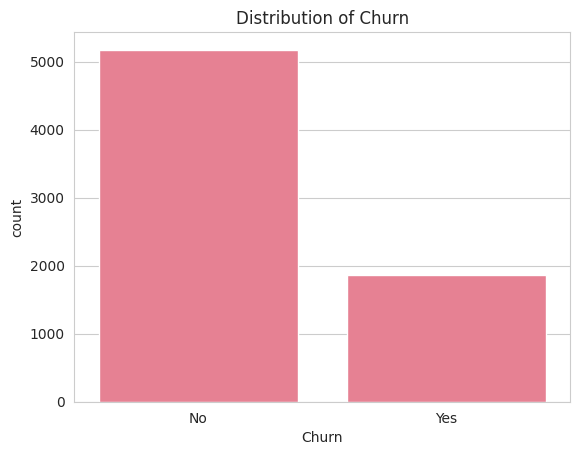

In [17]:
sns.countplot(x='Churn', data = df)
plt.title('Distribution of Churn')
plt.show()

Imbalanced dataset

In [18]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})

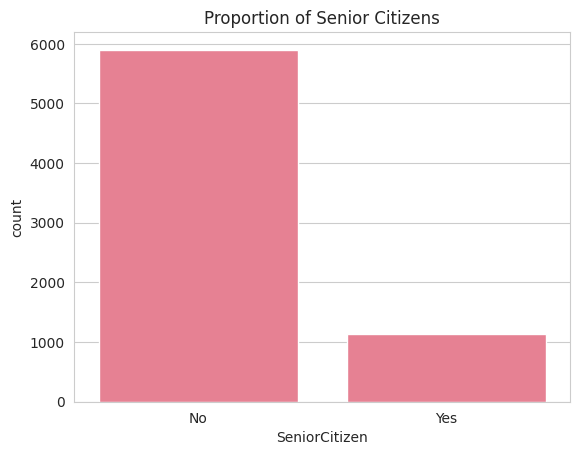

In [19]:
sns.countplot(x = 'SeniorCitizen', data=df)
plt.title("Proportion of Senior Citizens")
plt.show()

very few senior citizena

In [20]:
cat_features = [i for i in list(df.columns) if i not in list(df.describe().columns)]

In [21]:
cat_features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

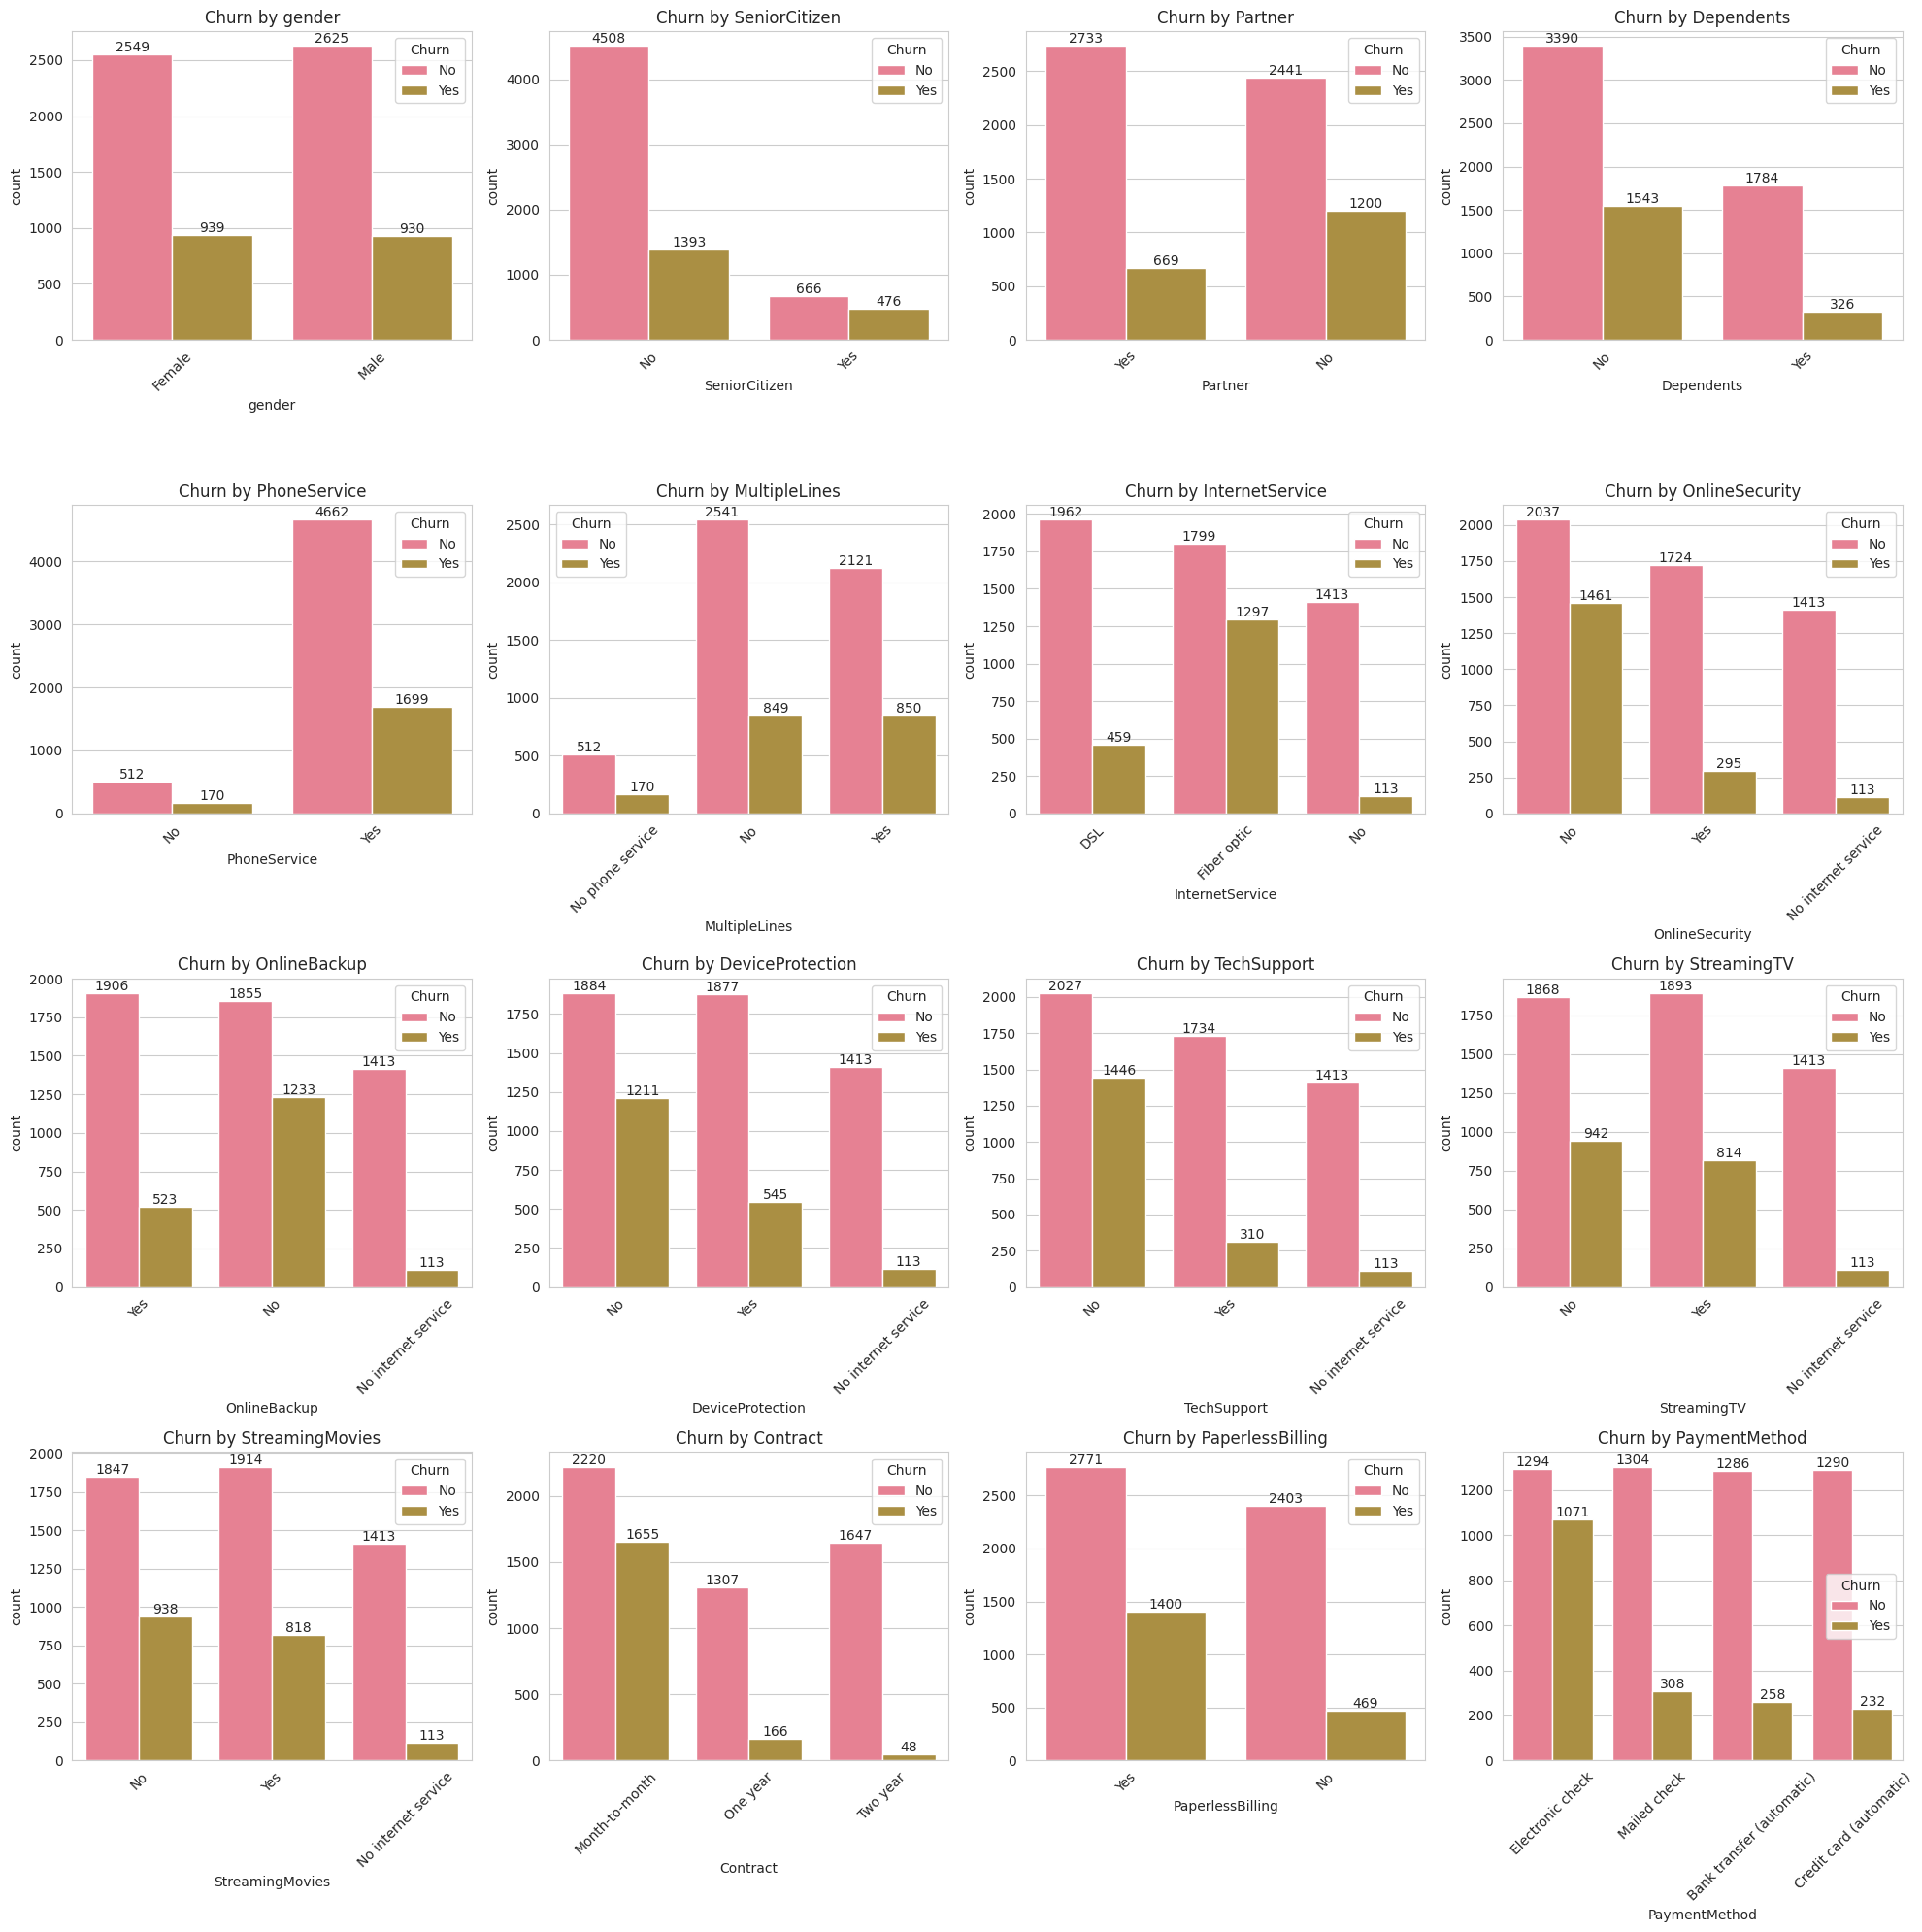

In [22]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
plot_idx = 0
for feature in cat_features:
    if feature == 'Churn':
        continue

    row = plot_idx // 4
    col = plot_idx % 4

    sns.countplot(x=feature, hue='Churn', data=df, ax=ax[row][col])
    ax[row][col].set_title(f'Churn by {feature}')
    ax[row][col].tick_params(axis='x', rotation=45)
    for container in ax[row][col].containers:
        ax[row][col].bar_label(container)

    plot_idx += 1

plt.tight_layout()
plt.show()

Gender almost same proportions for both female and male.
Senior citizens tend to churn more.
No partner churn more.
No dependents churn more.


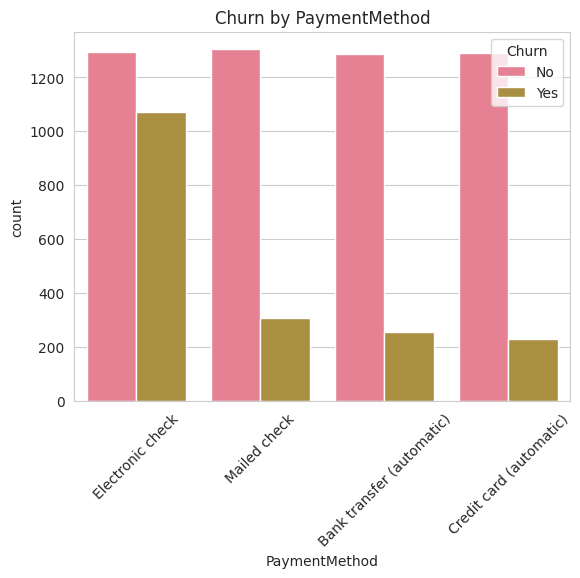

In [23]:
sns.countplot(x = "PaymentMethod", data=df, hue='Churn')
plt.title("Churn by PaymentMethod")
plt.xticks(rotation=45)
plt.show()

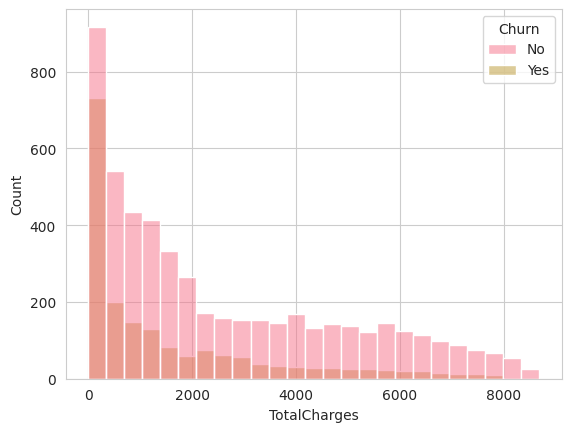

In [24]:
sns.histplot(x='TotalCharges', hue='Churn', data=df)
plt.show()

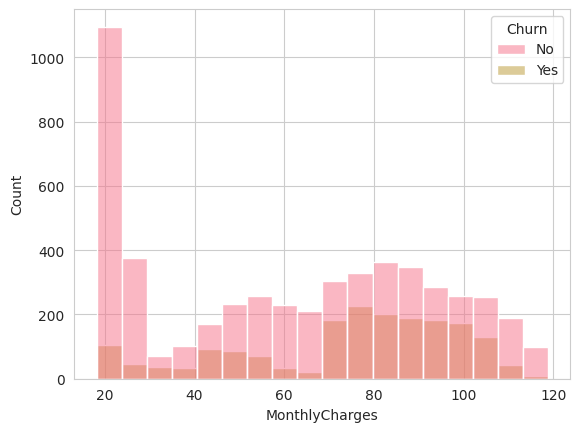

In [25]:
sns.histplot(x='MonthlyCharges', hue='Churn', data=df)
plt.show()

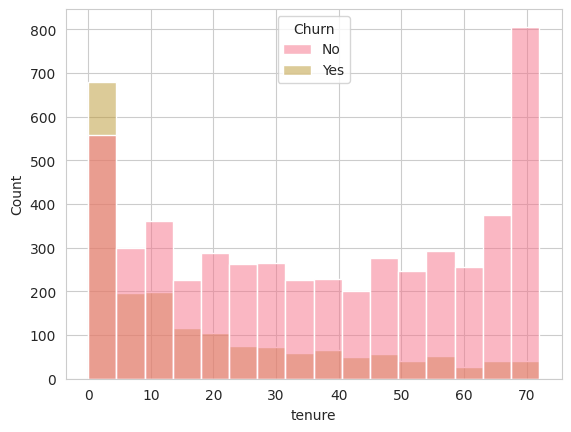

In [26]:
sns.histplot(x='tenure', hue='Churn', data=df)
plt.show()

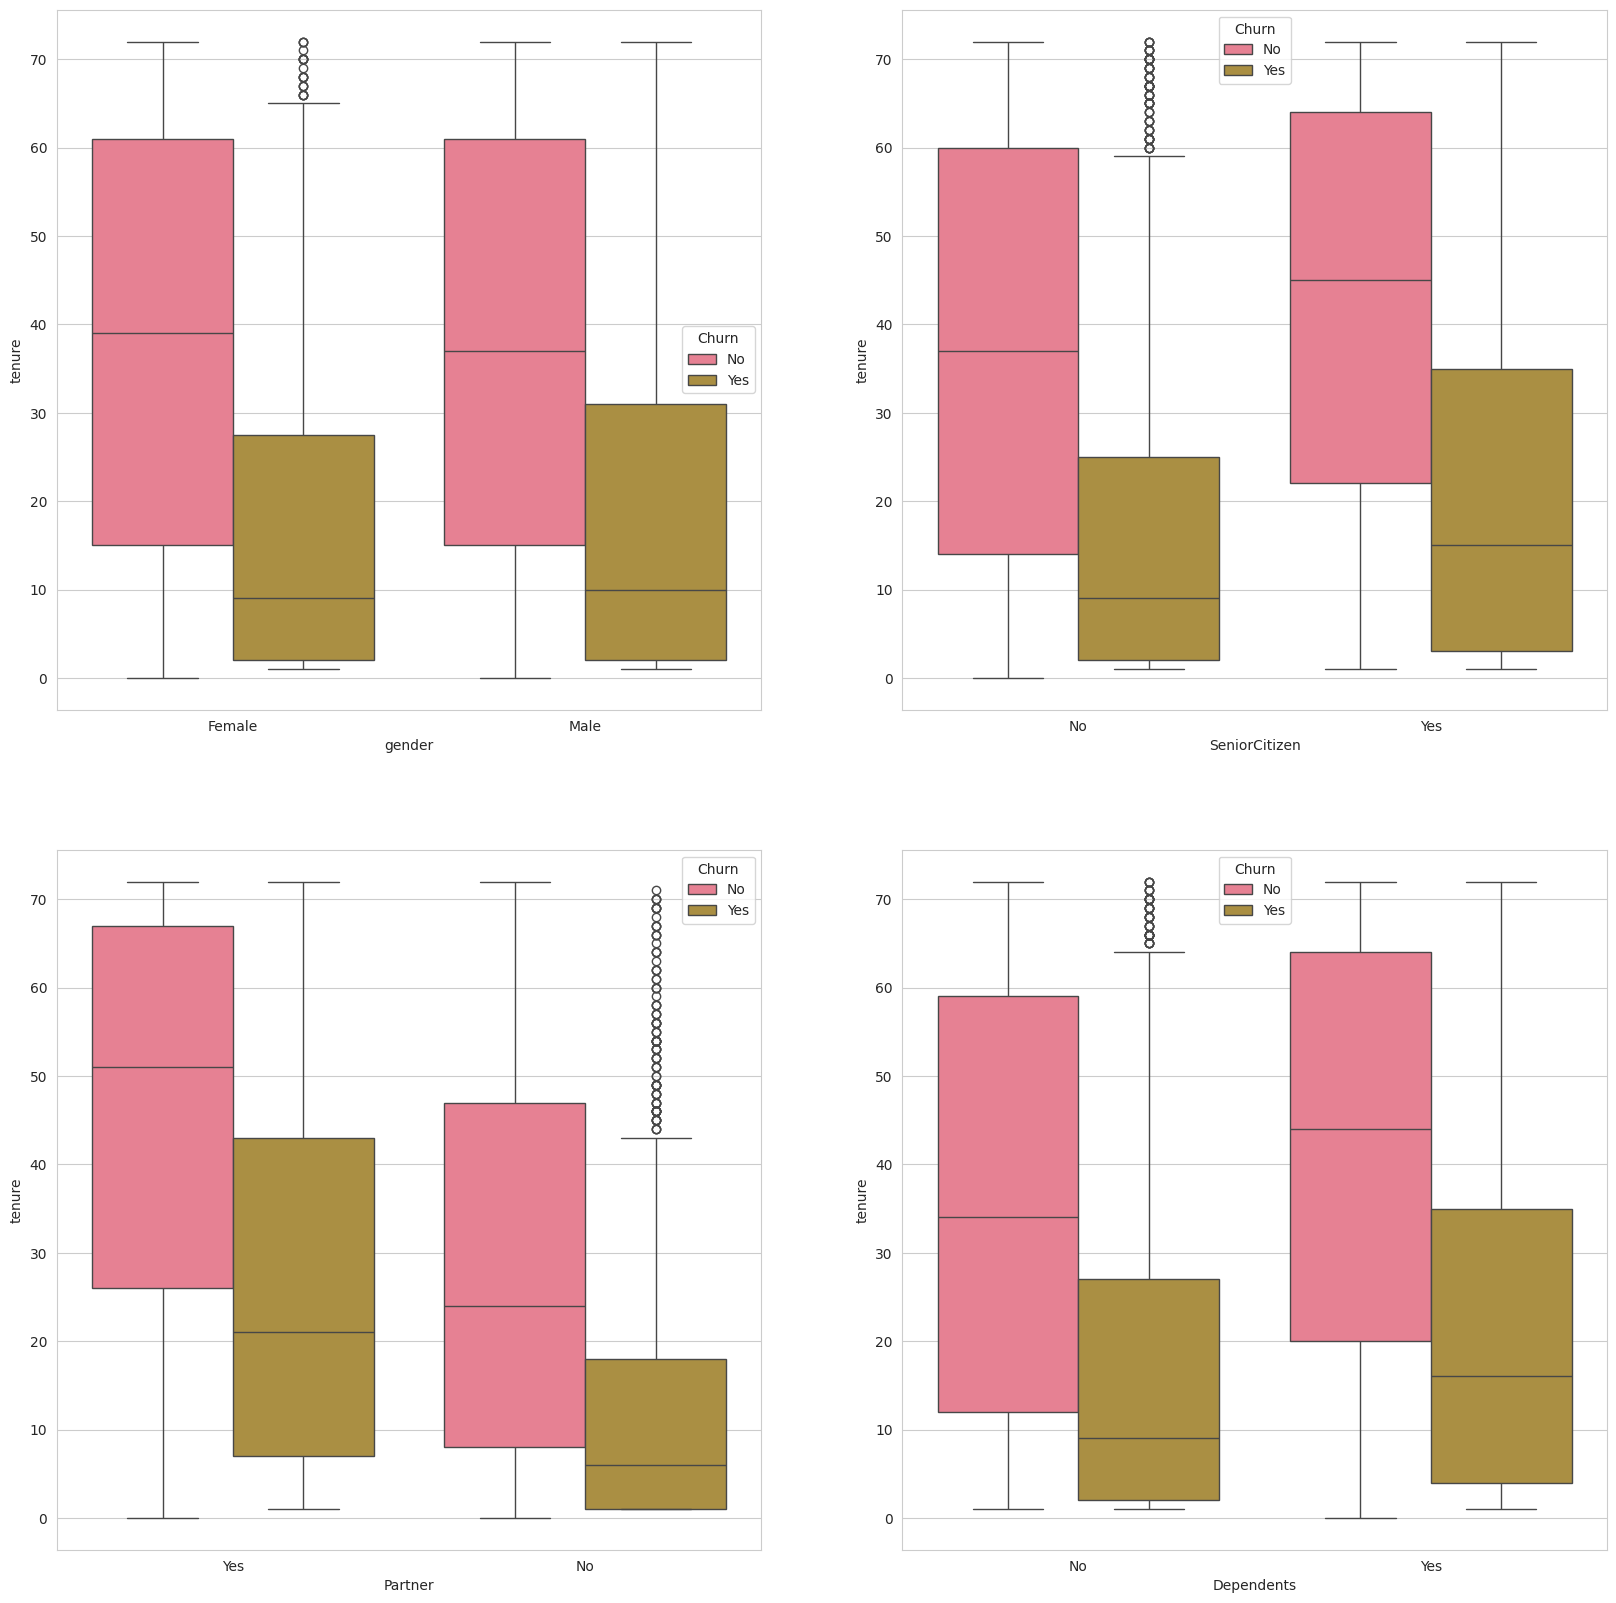

In [27]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x1 = ['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x1[i] , y='tenure', data =df, hue='Churn')

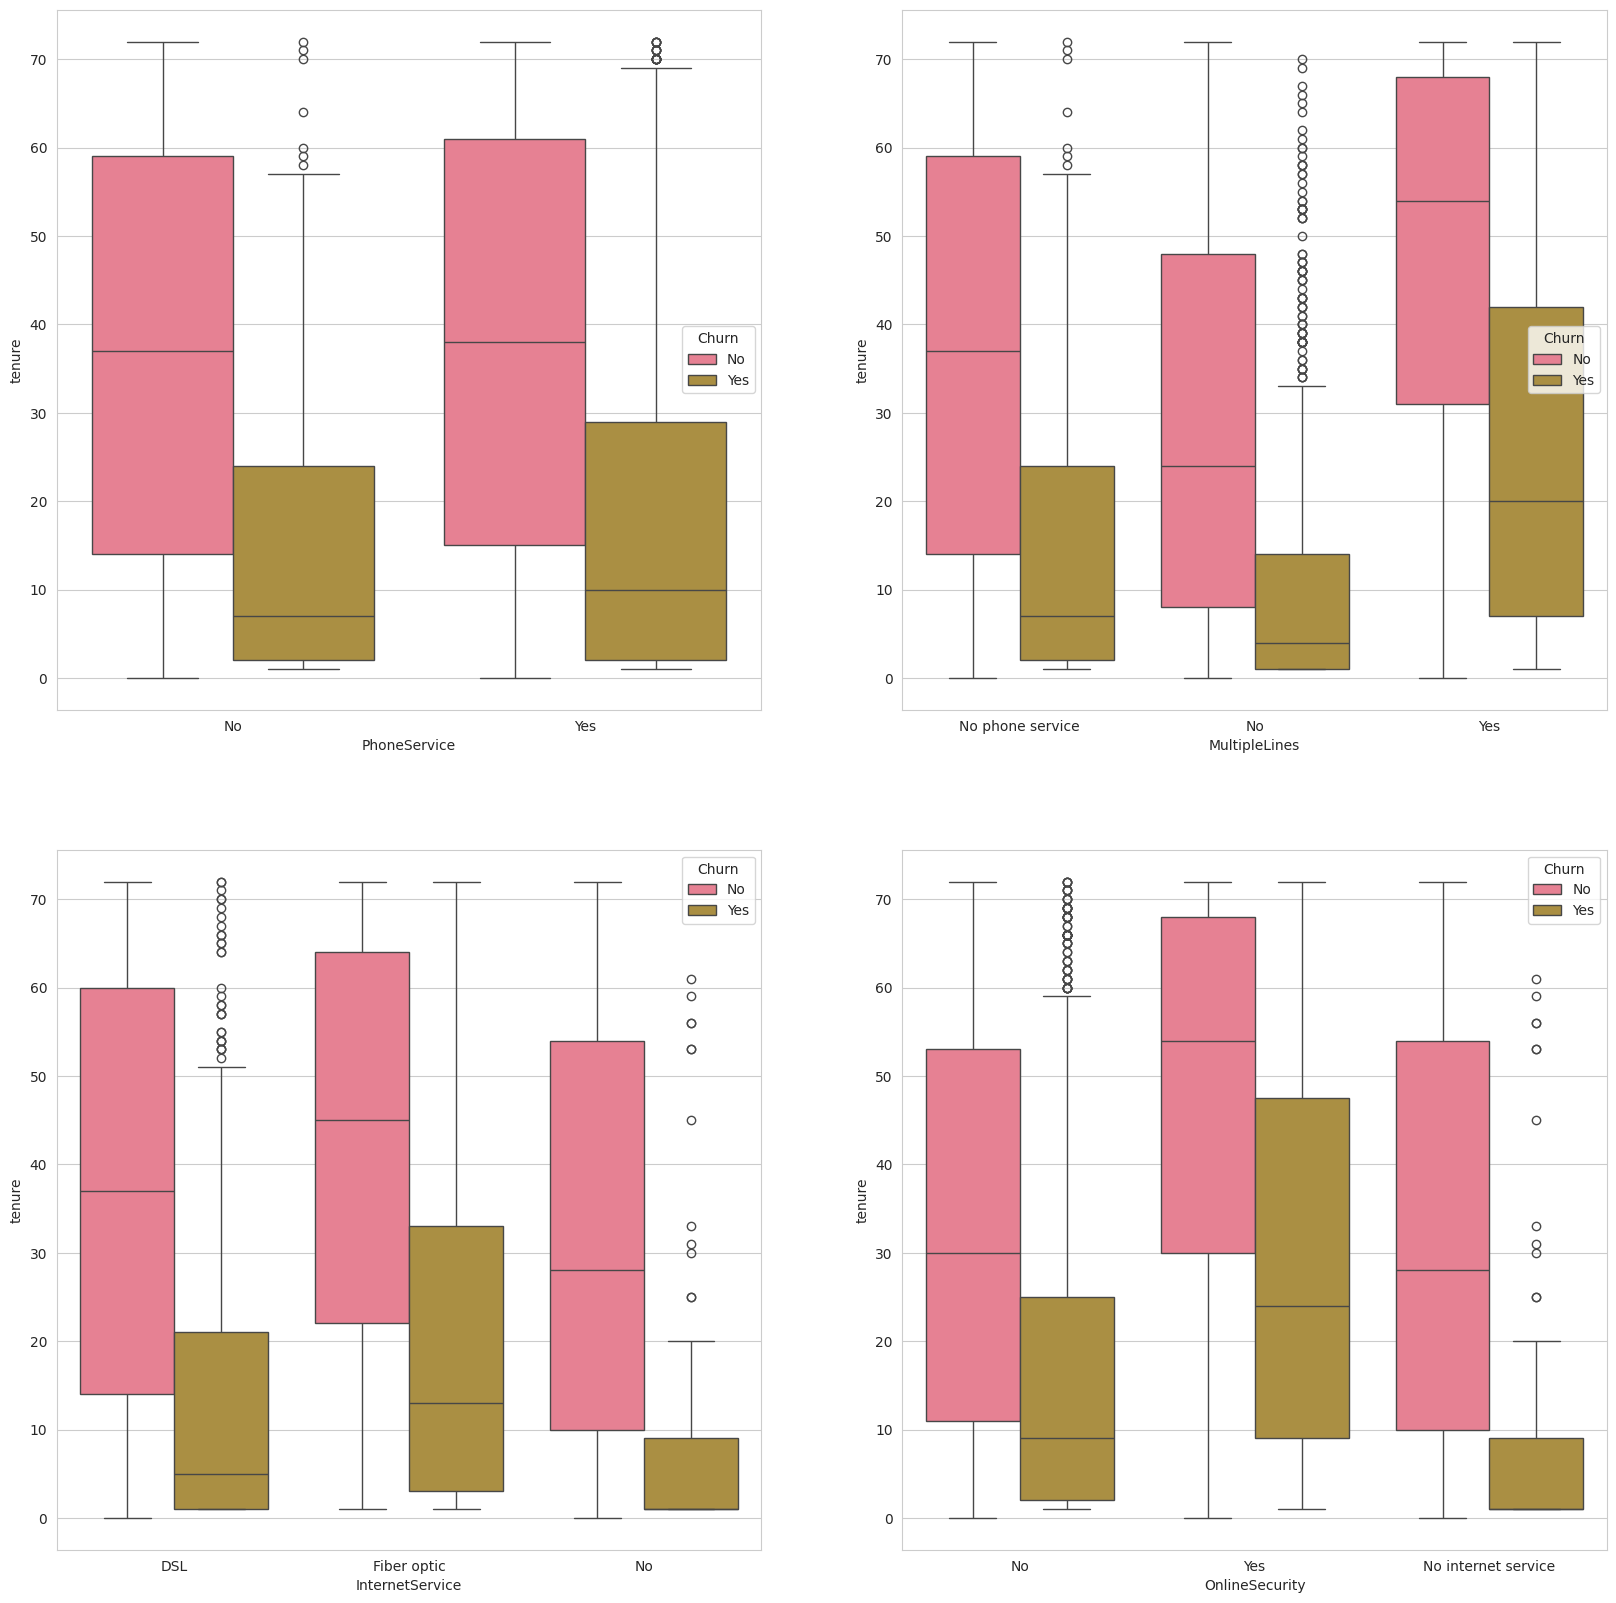

In [28]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x2 = ['PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x2[i] , y='tenure', data =df, hue='Churn')

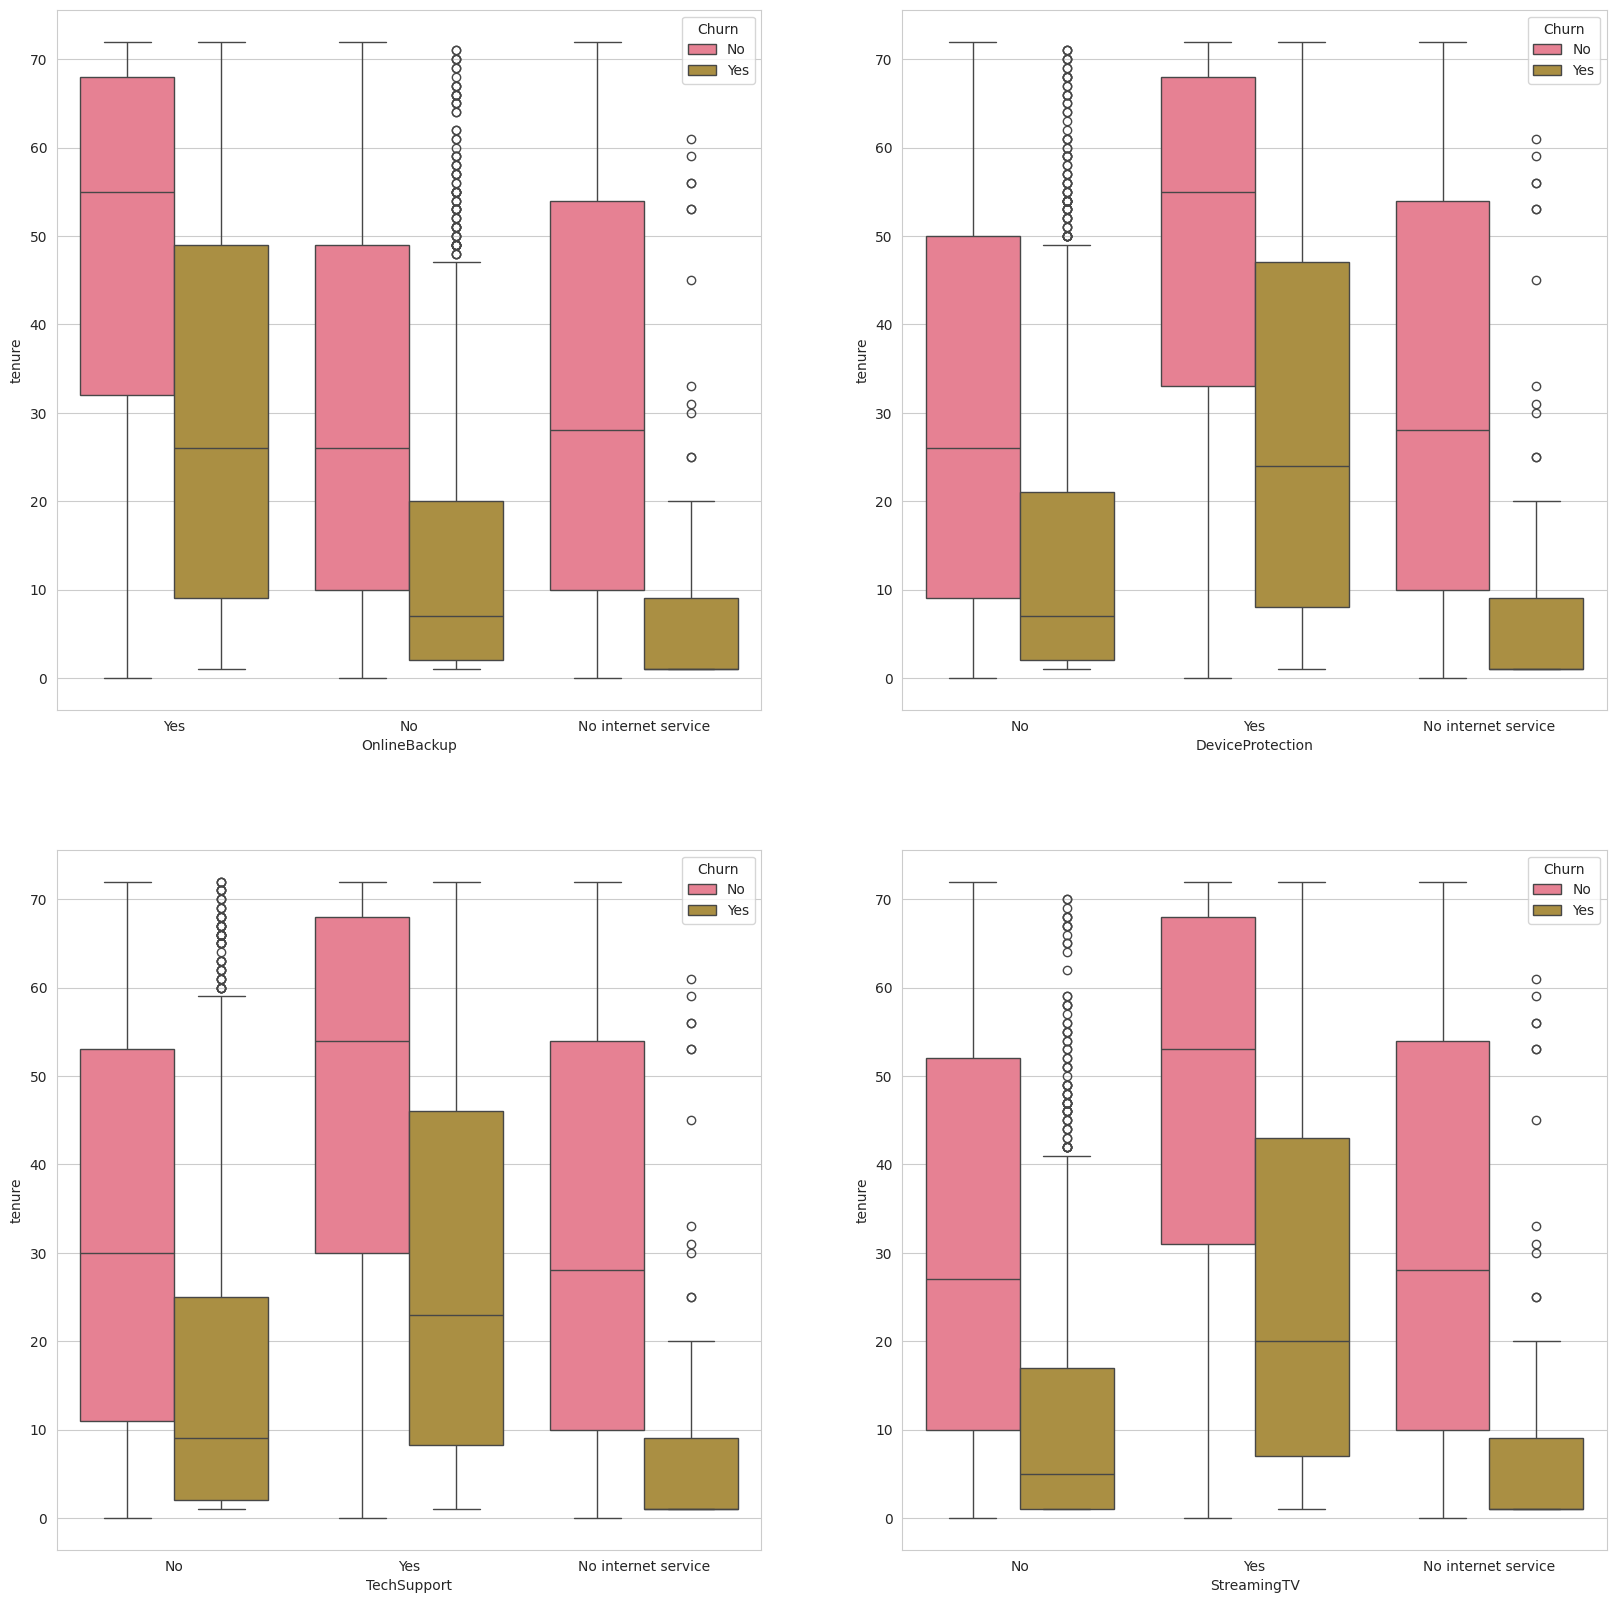

In [29]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x3 = ['OnlineBackup',
 'DeviceProtection', 
 'TechSupport',
 'StreamingTV']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x3[i] , y='tenure', data =df, hue='Churn')

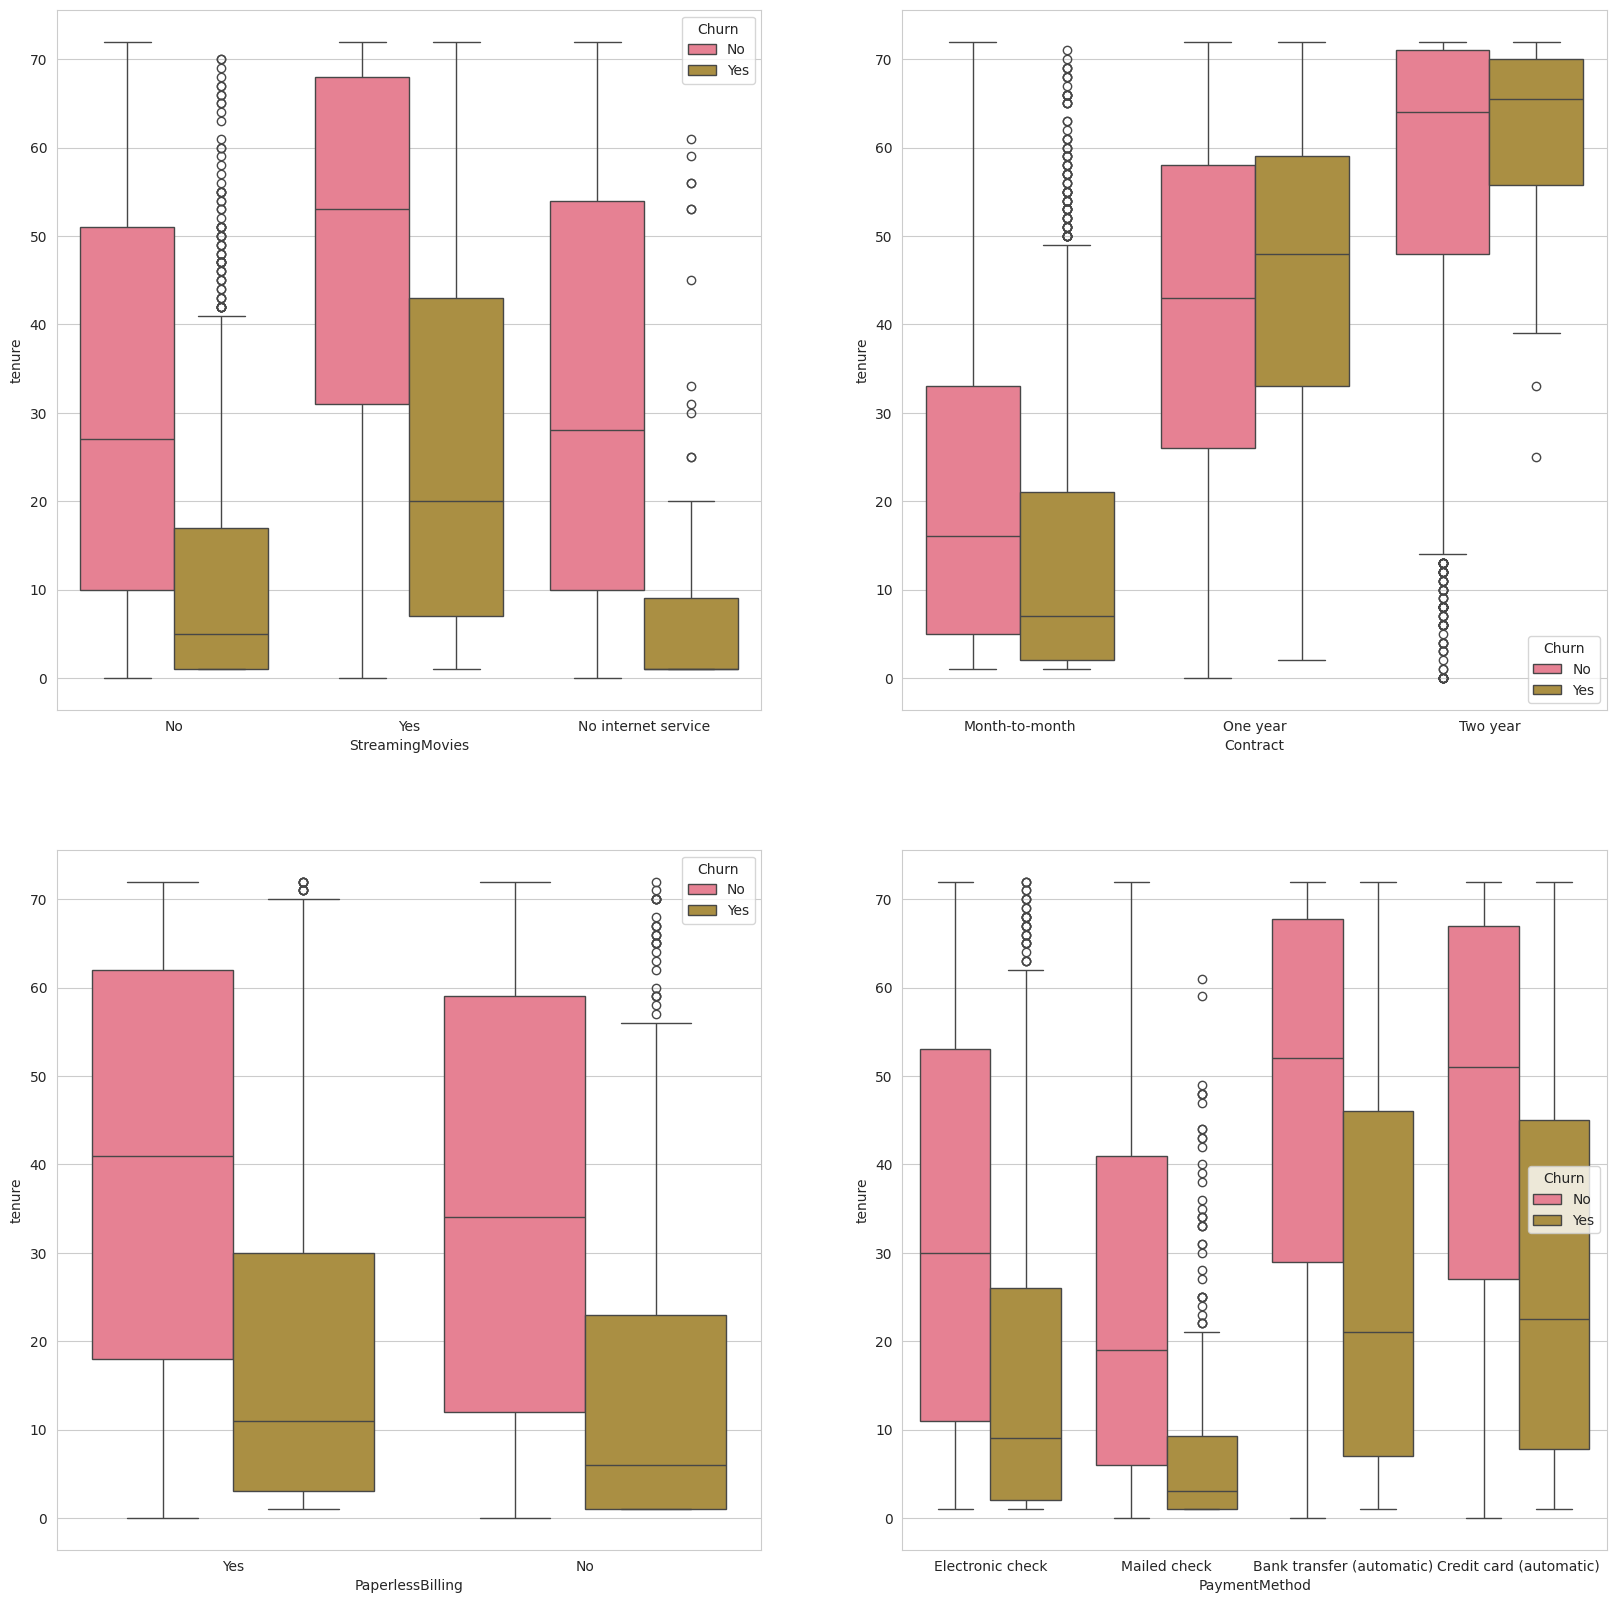

In [30]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x4 = ['StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x4[i] , y='tenure', data =df, hue='Churn')

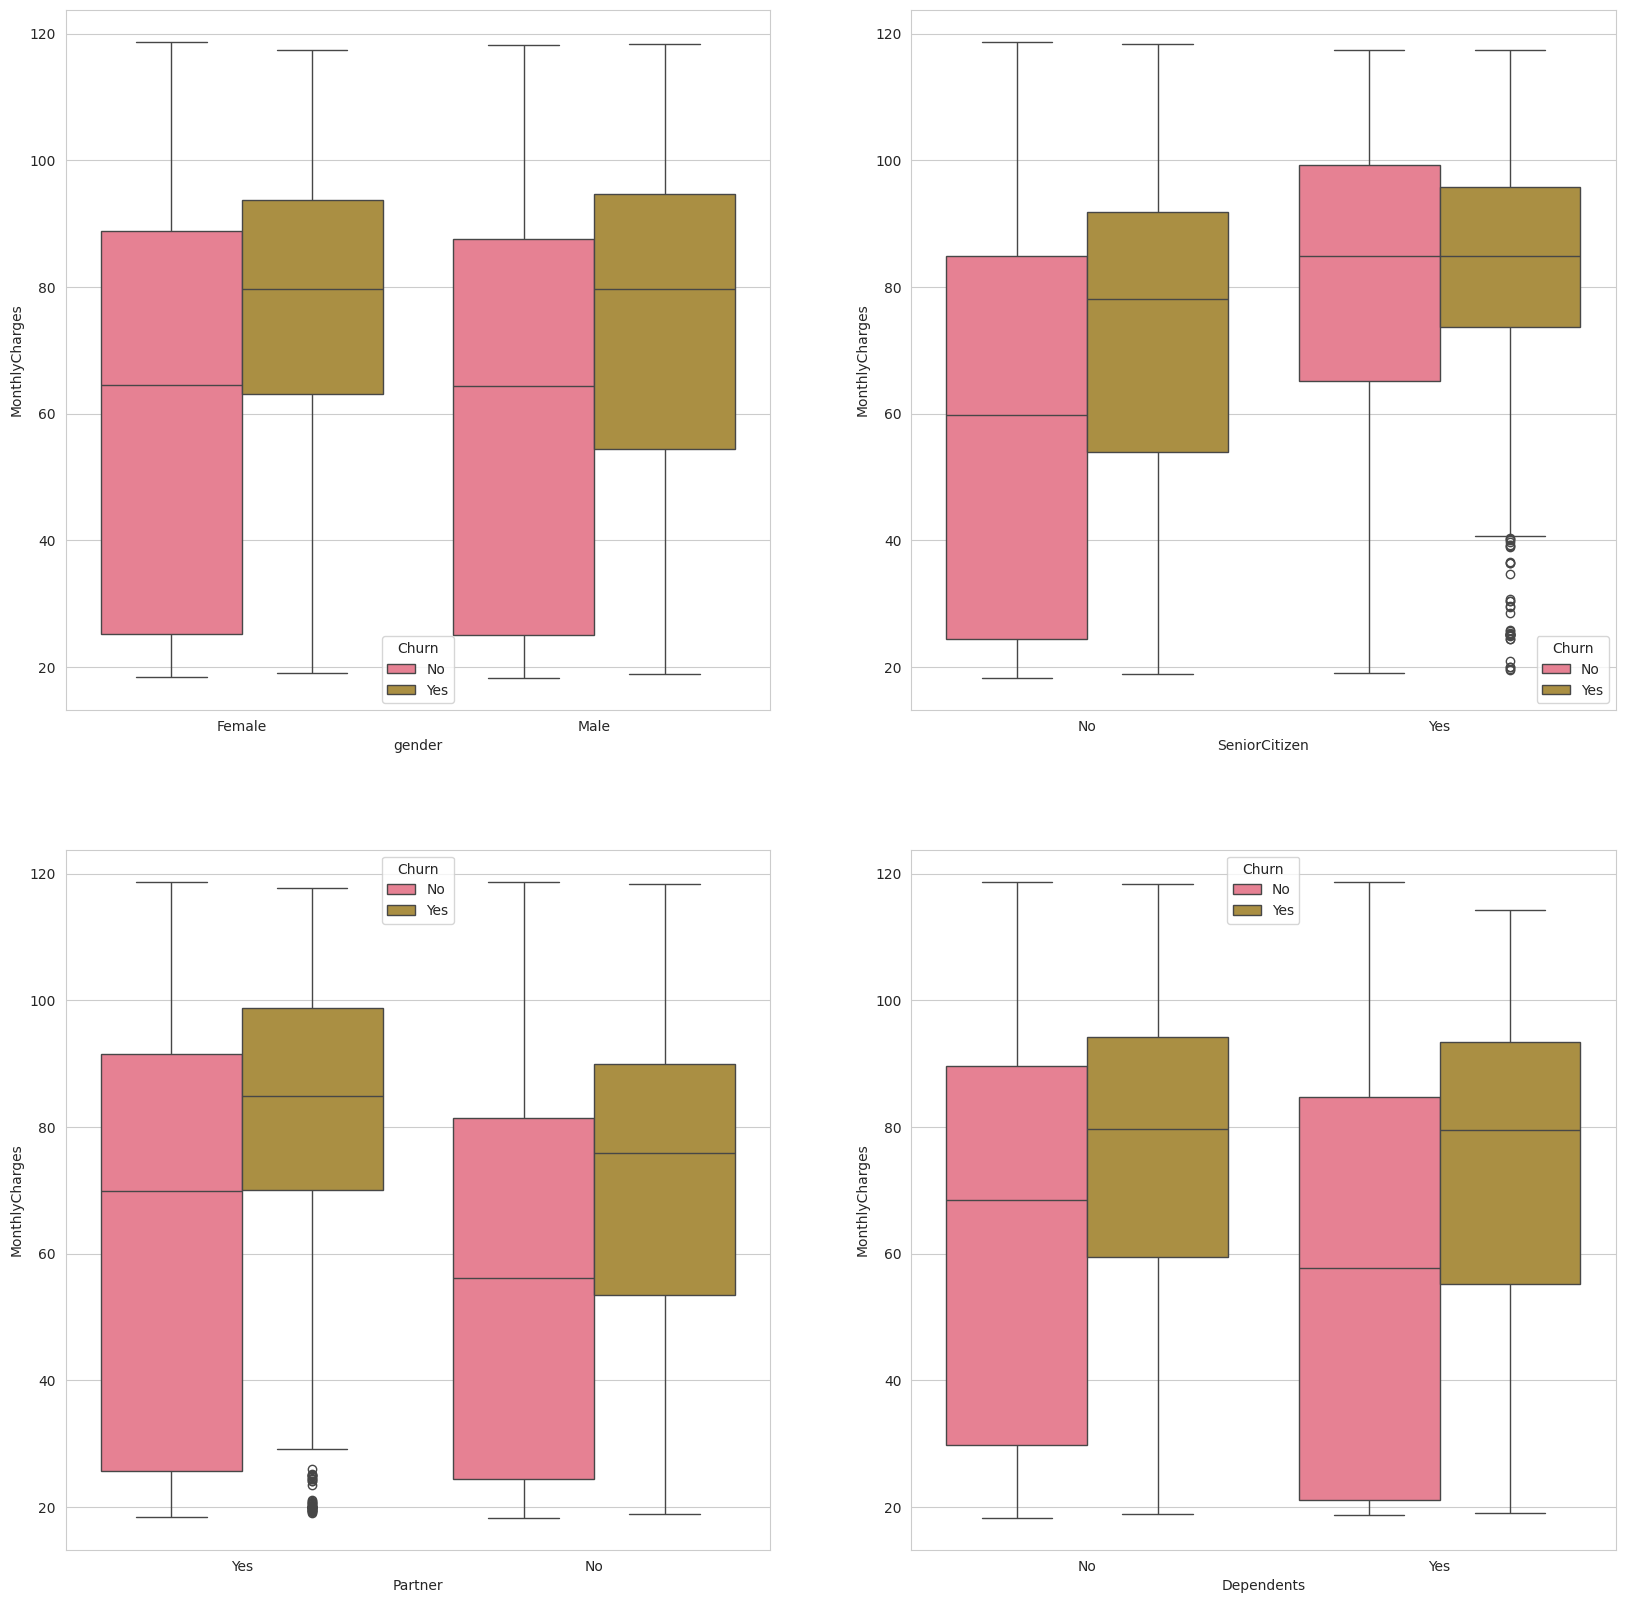

In [31]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x1 = ['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x1[i] , y='MonthlyCharges', data =df, hue='Churn')

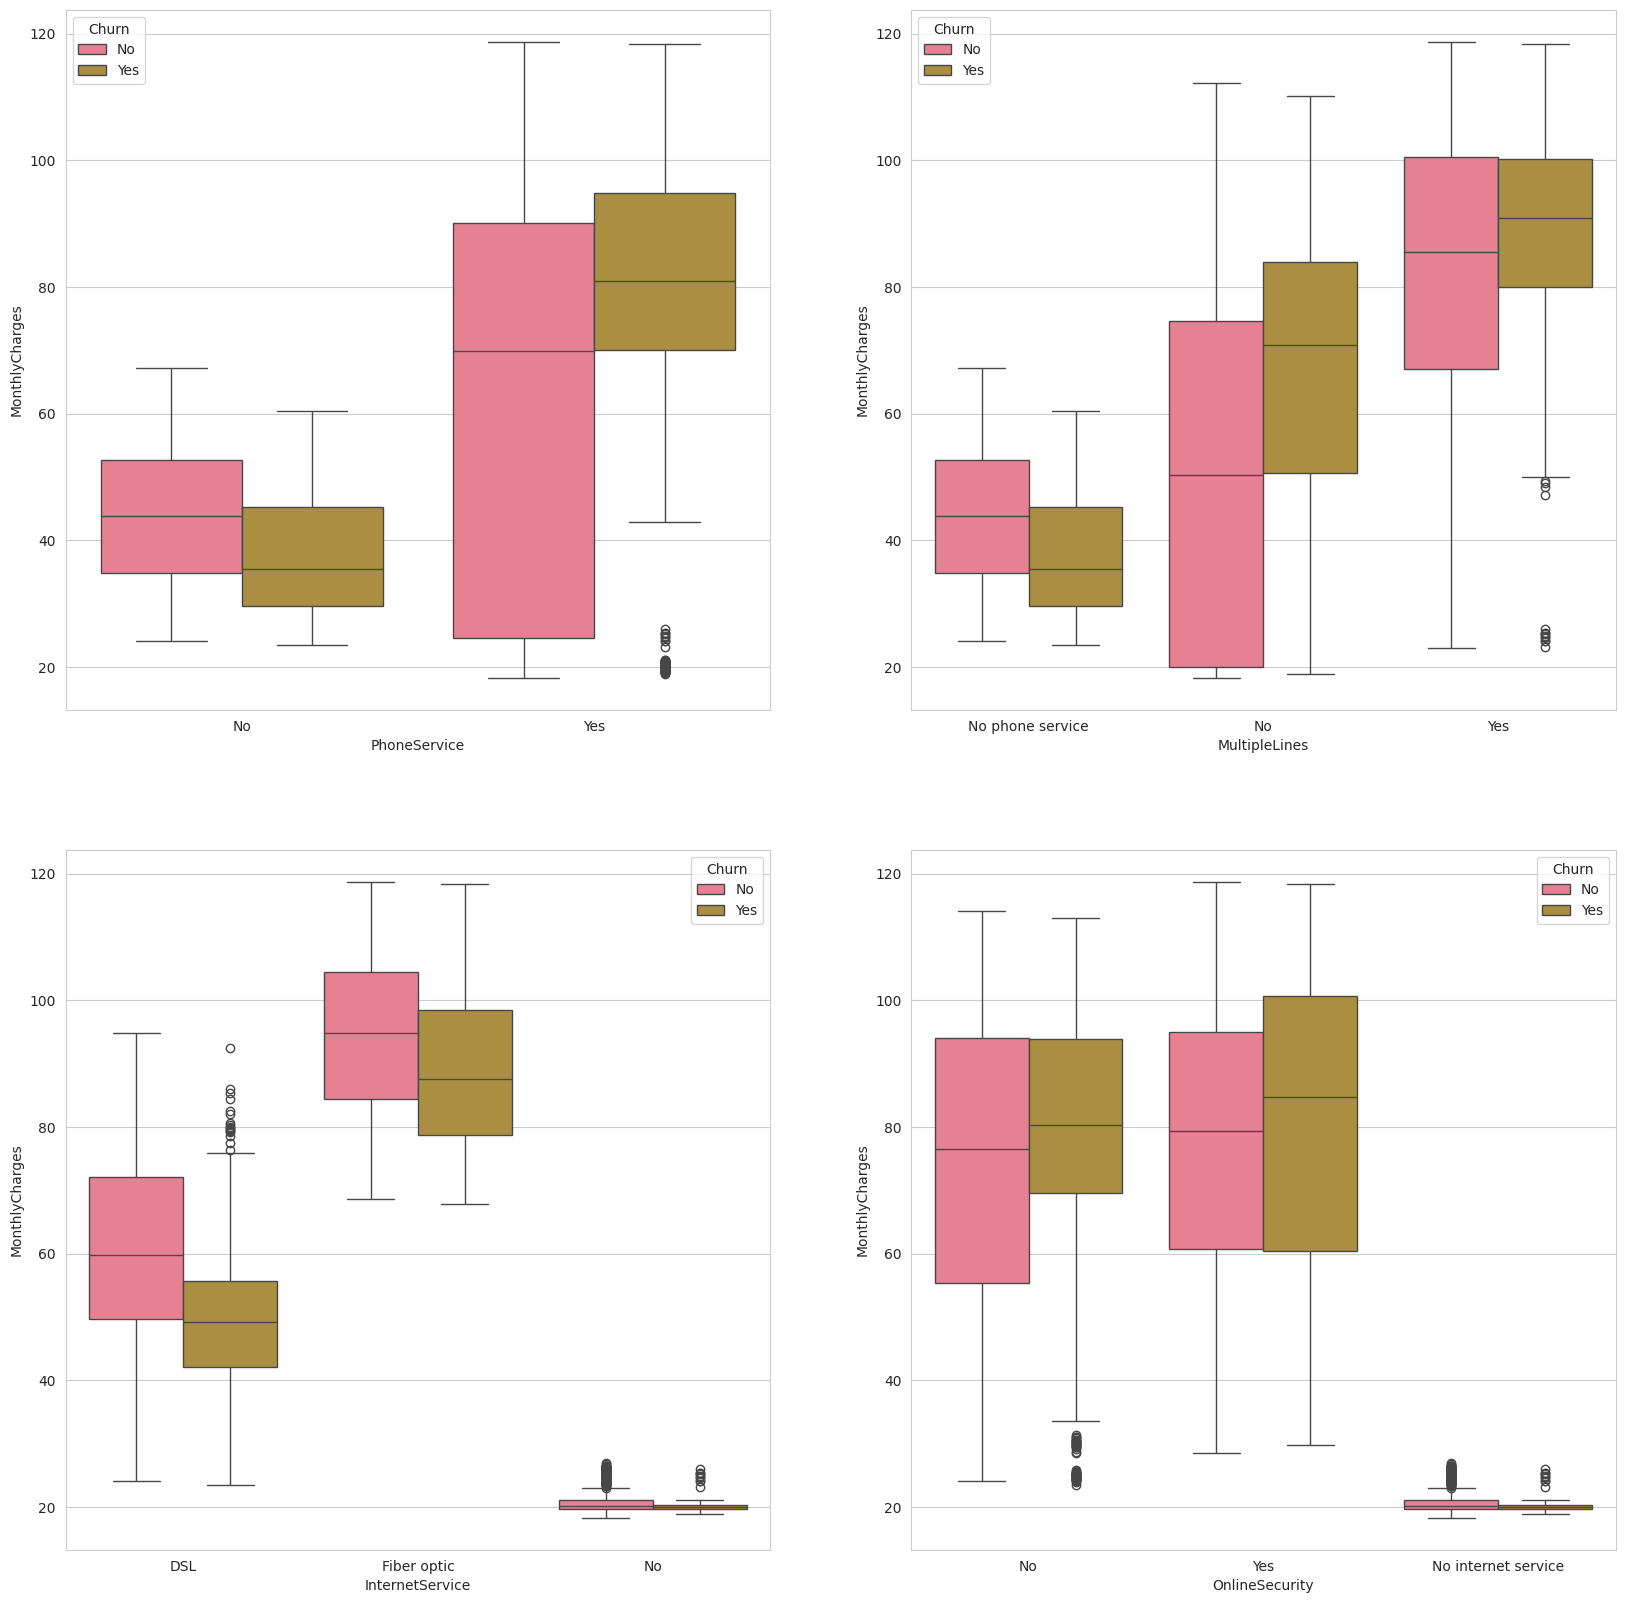

In [32]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x2 = ['PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x2[i] , y='MonthlyCharges', data =df, hue='Churn')

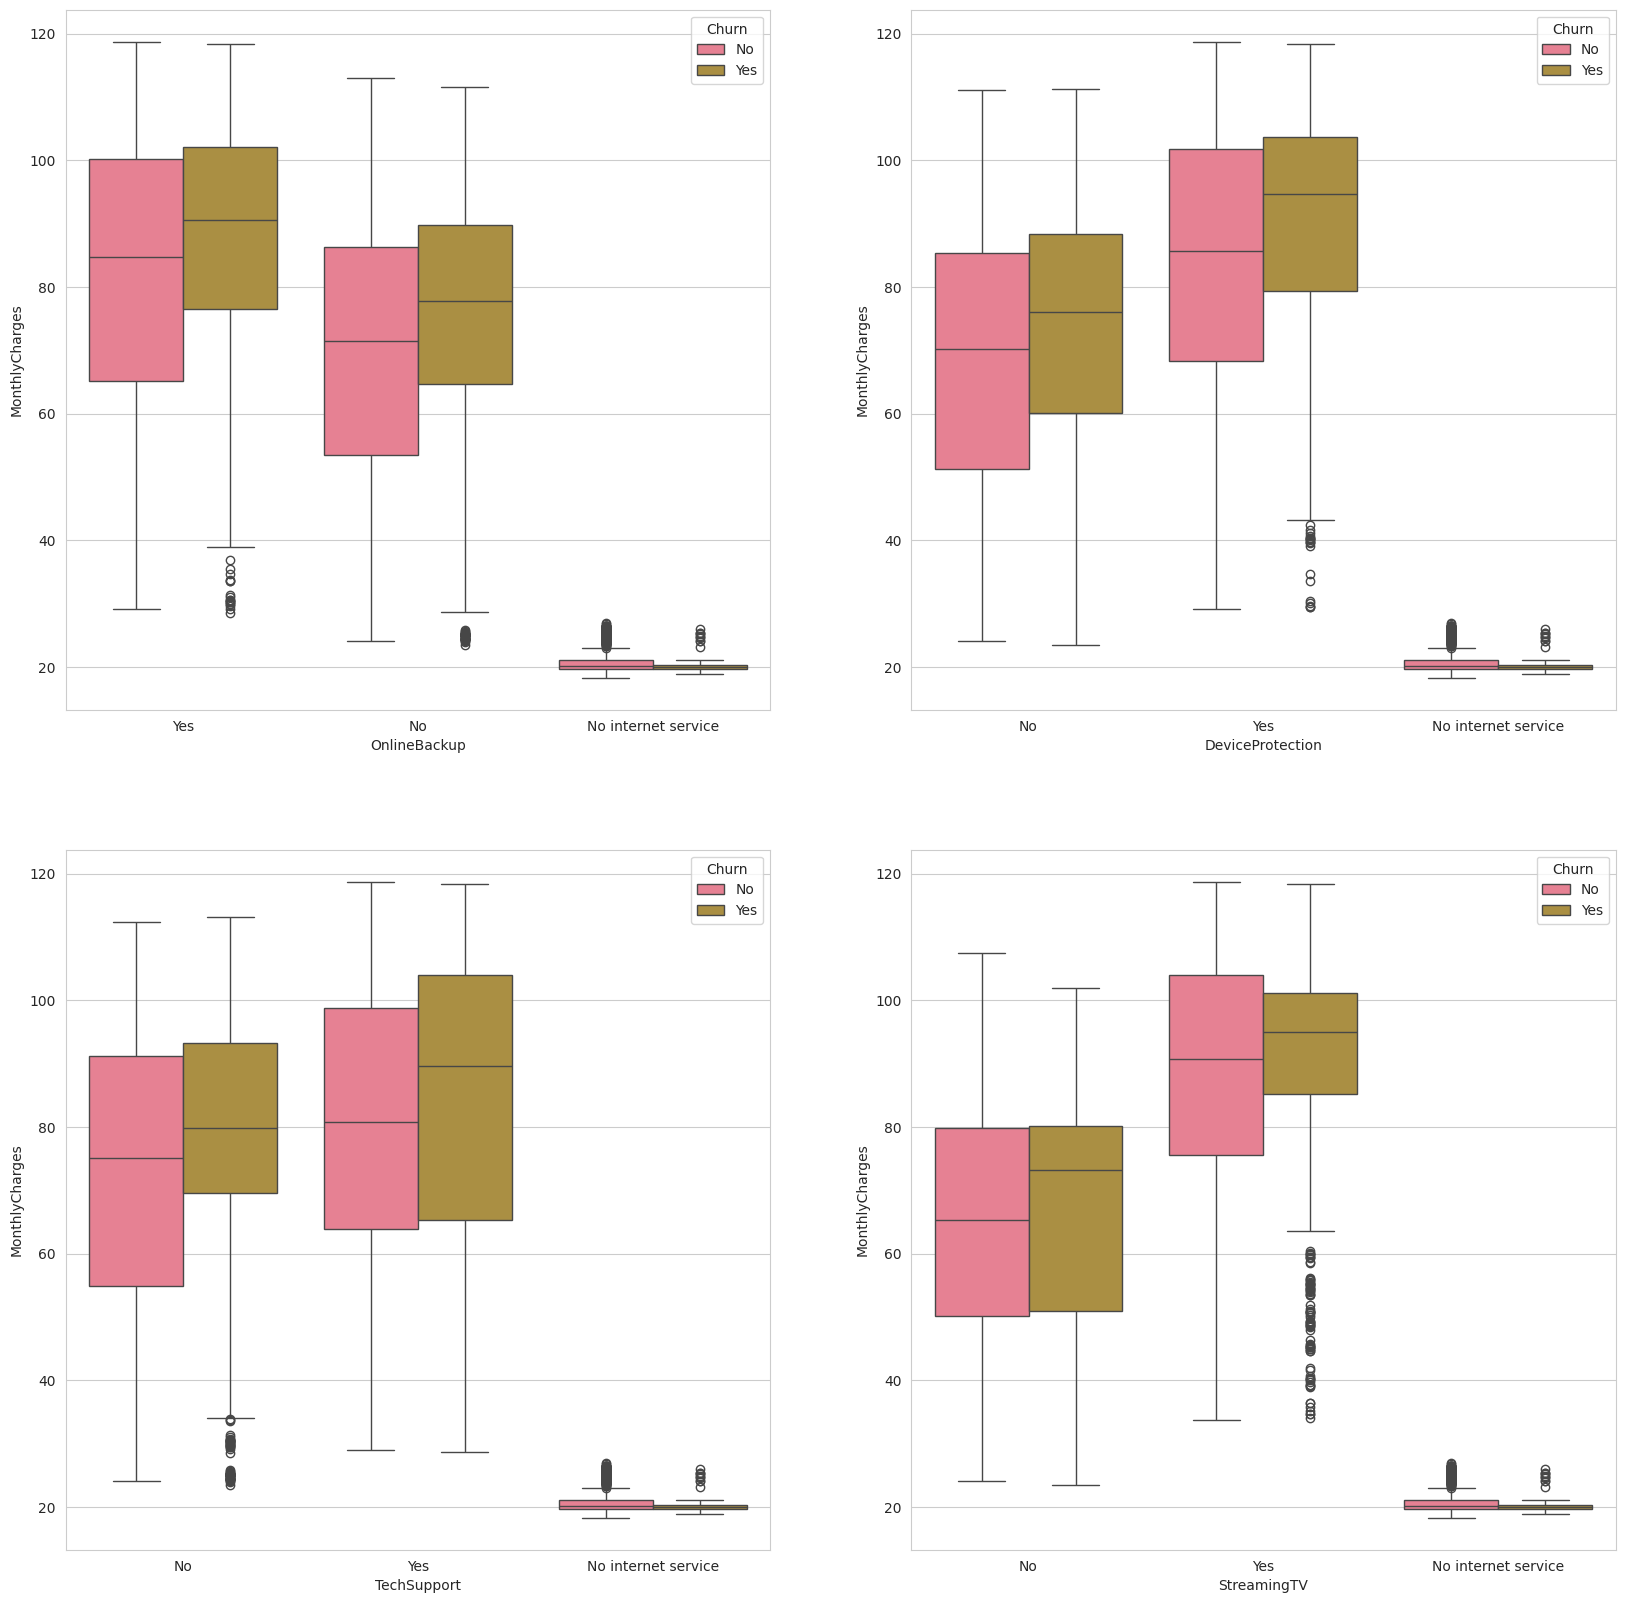

In [33]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x3 = ['OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x3[i] , y='MonthlyCharges', data =df, hue='Churn')

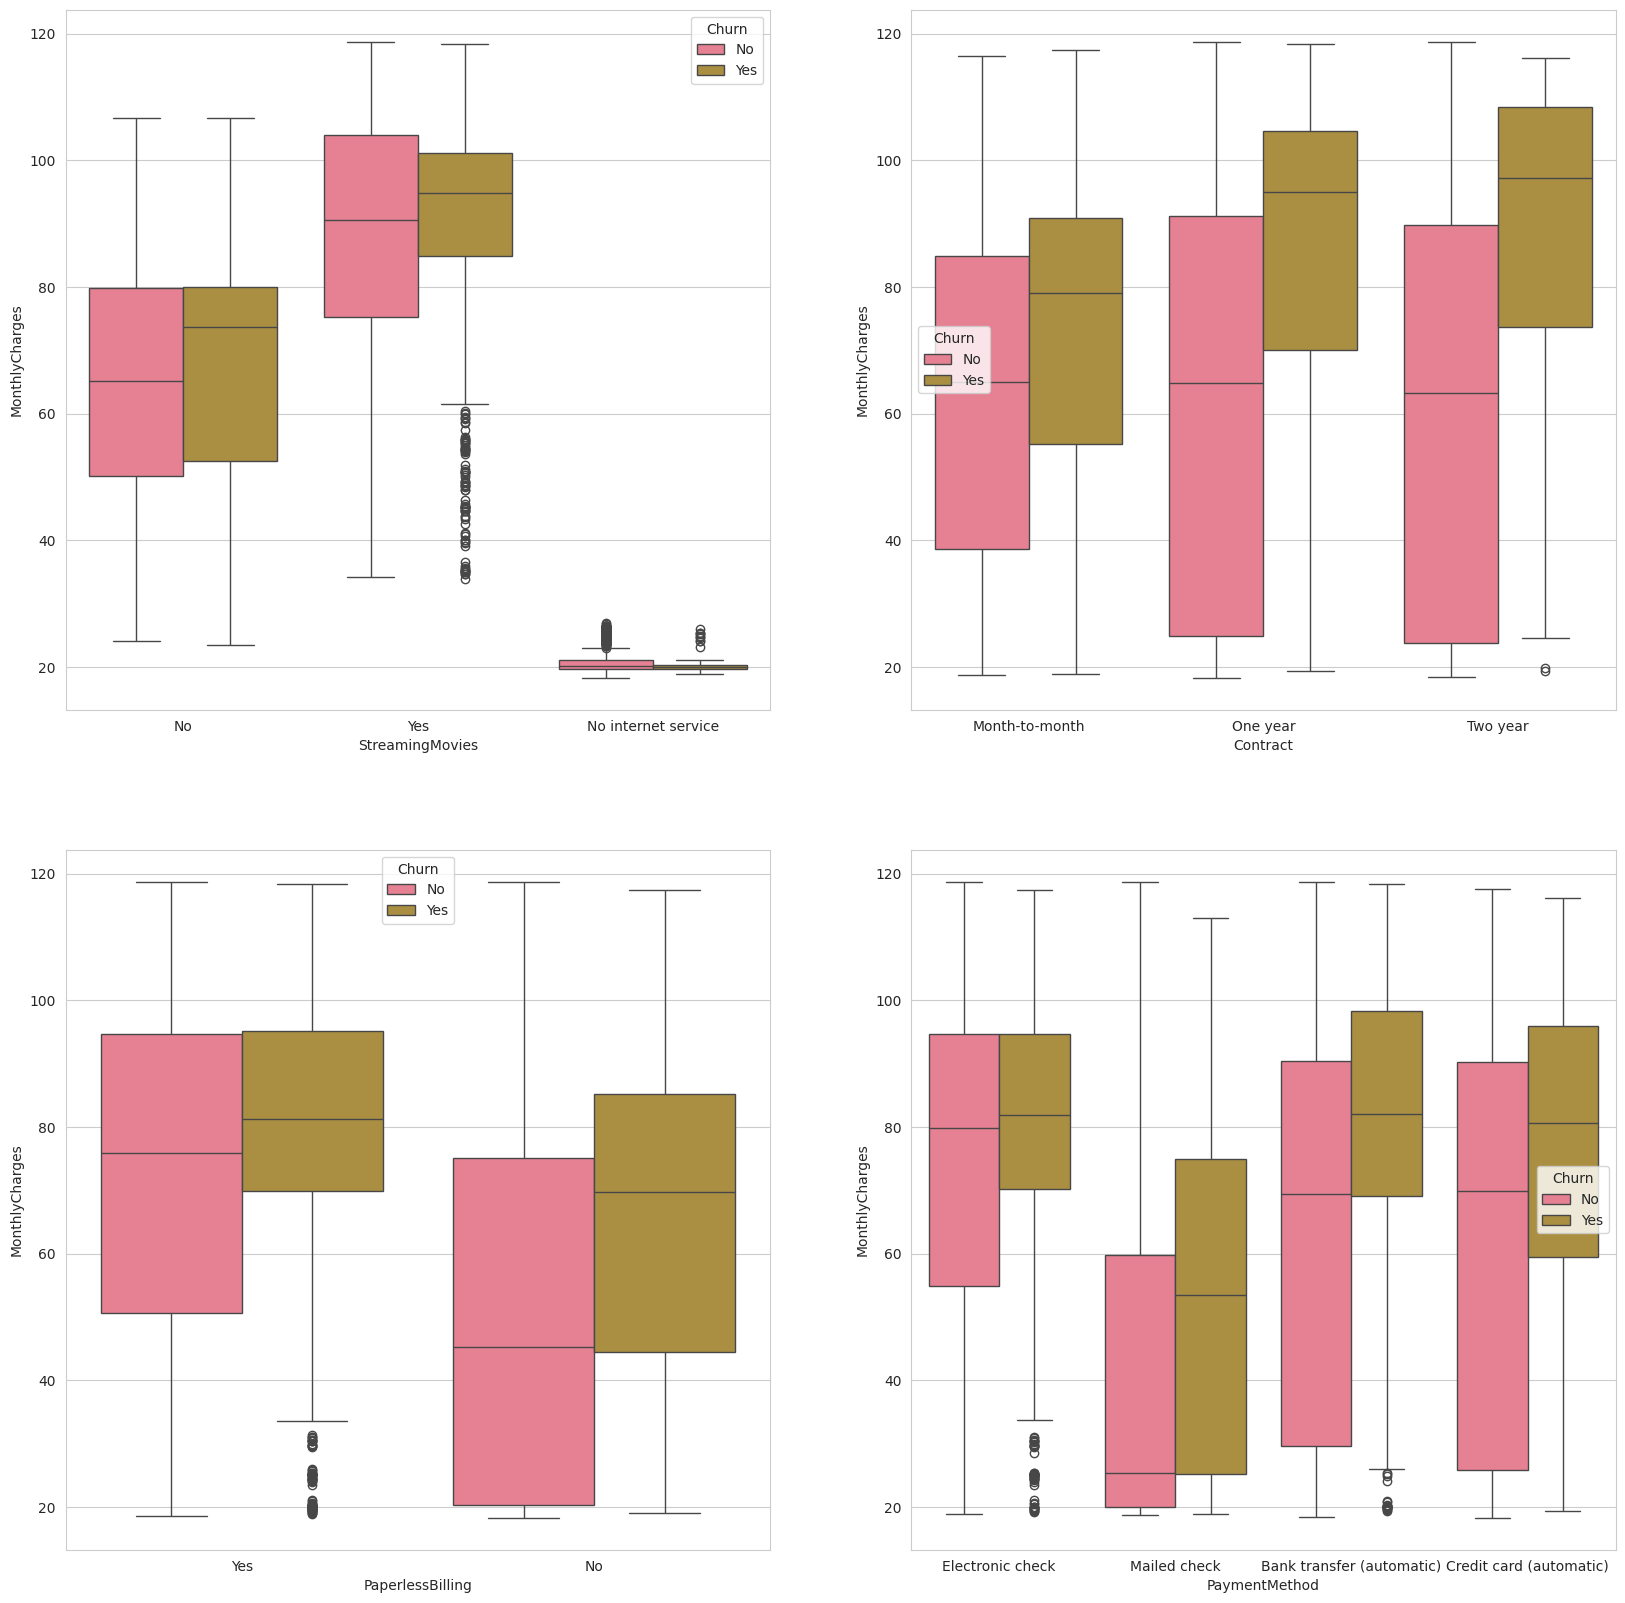

In [34]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x4 = ['StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x4[i] , y='MonthlyCharges', data =df, hue='Churn')

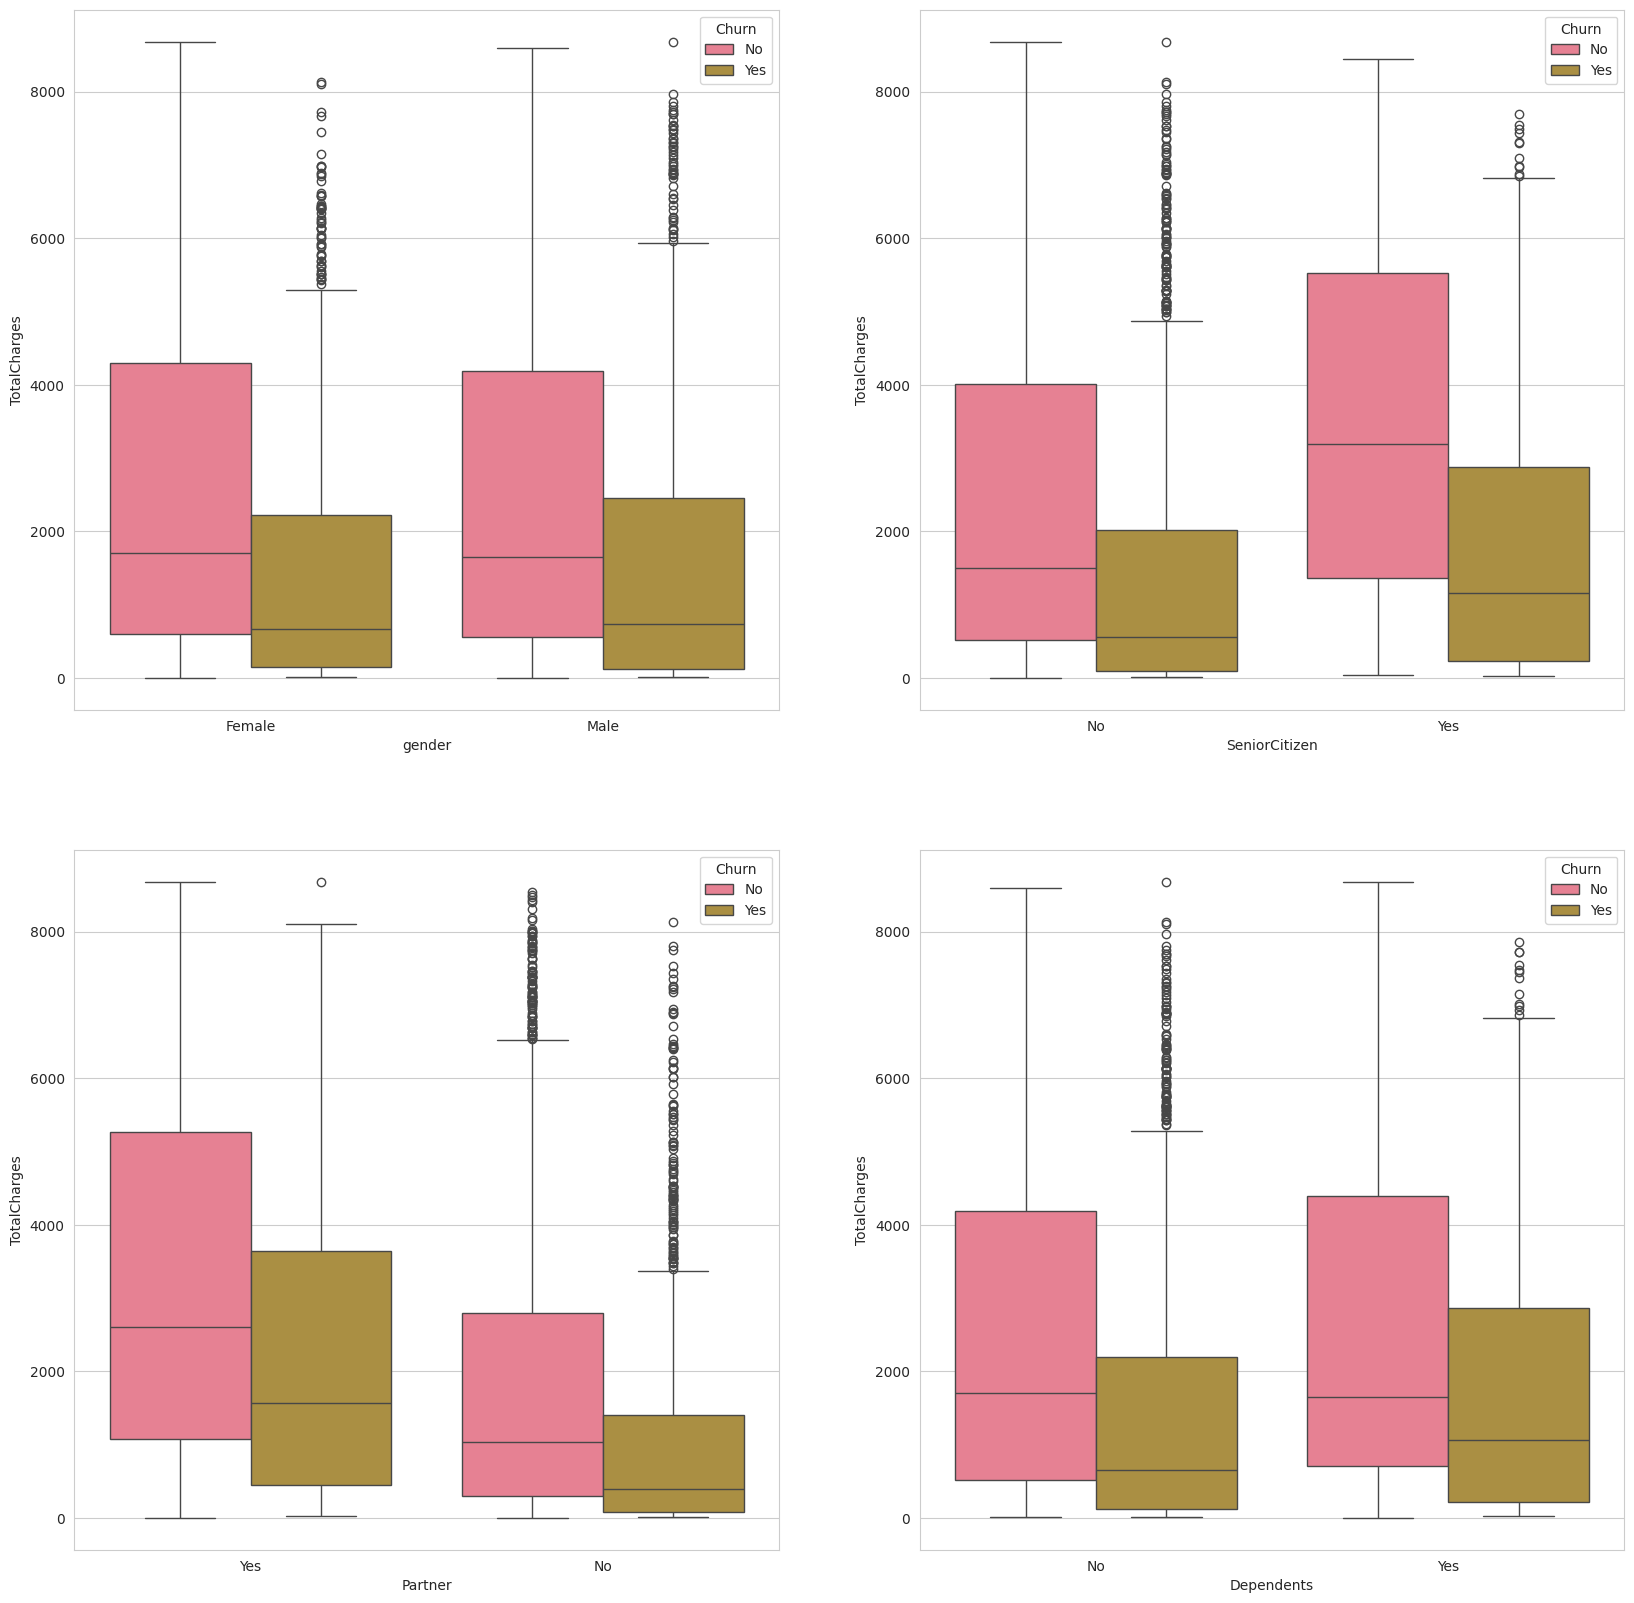

In [35]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x1 = ['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x1[i] , y='TotalCharges', data =df, hue='Churn')

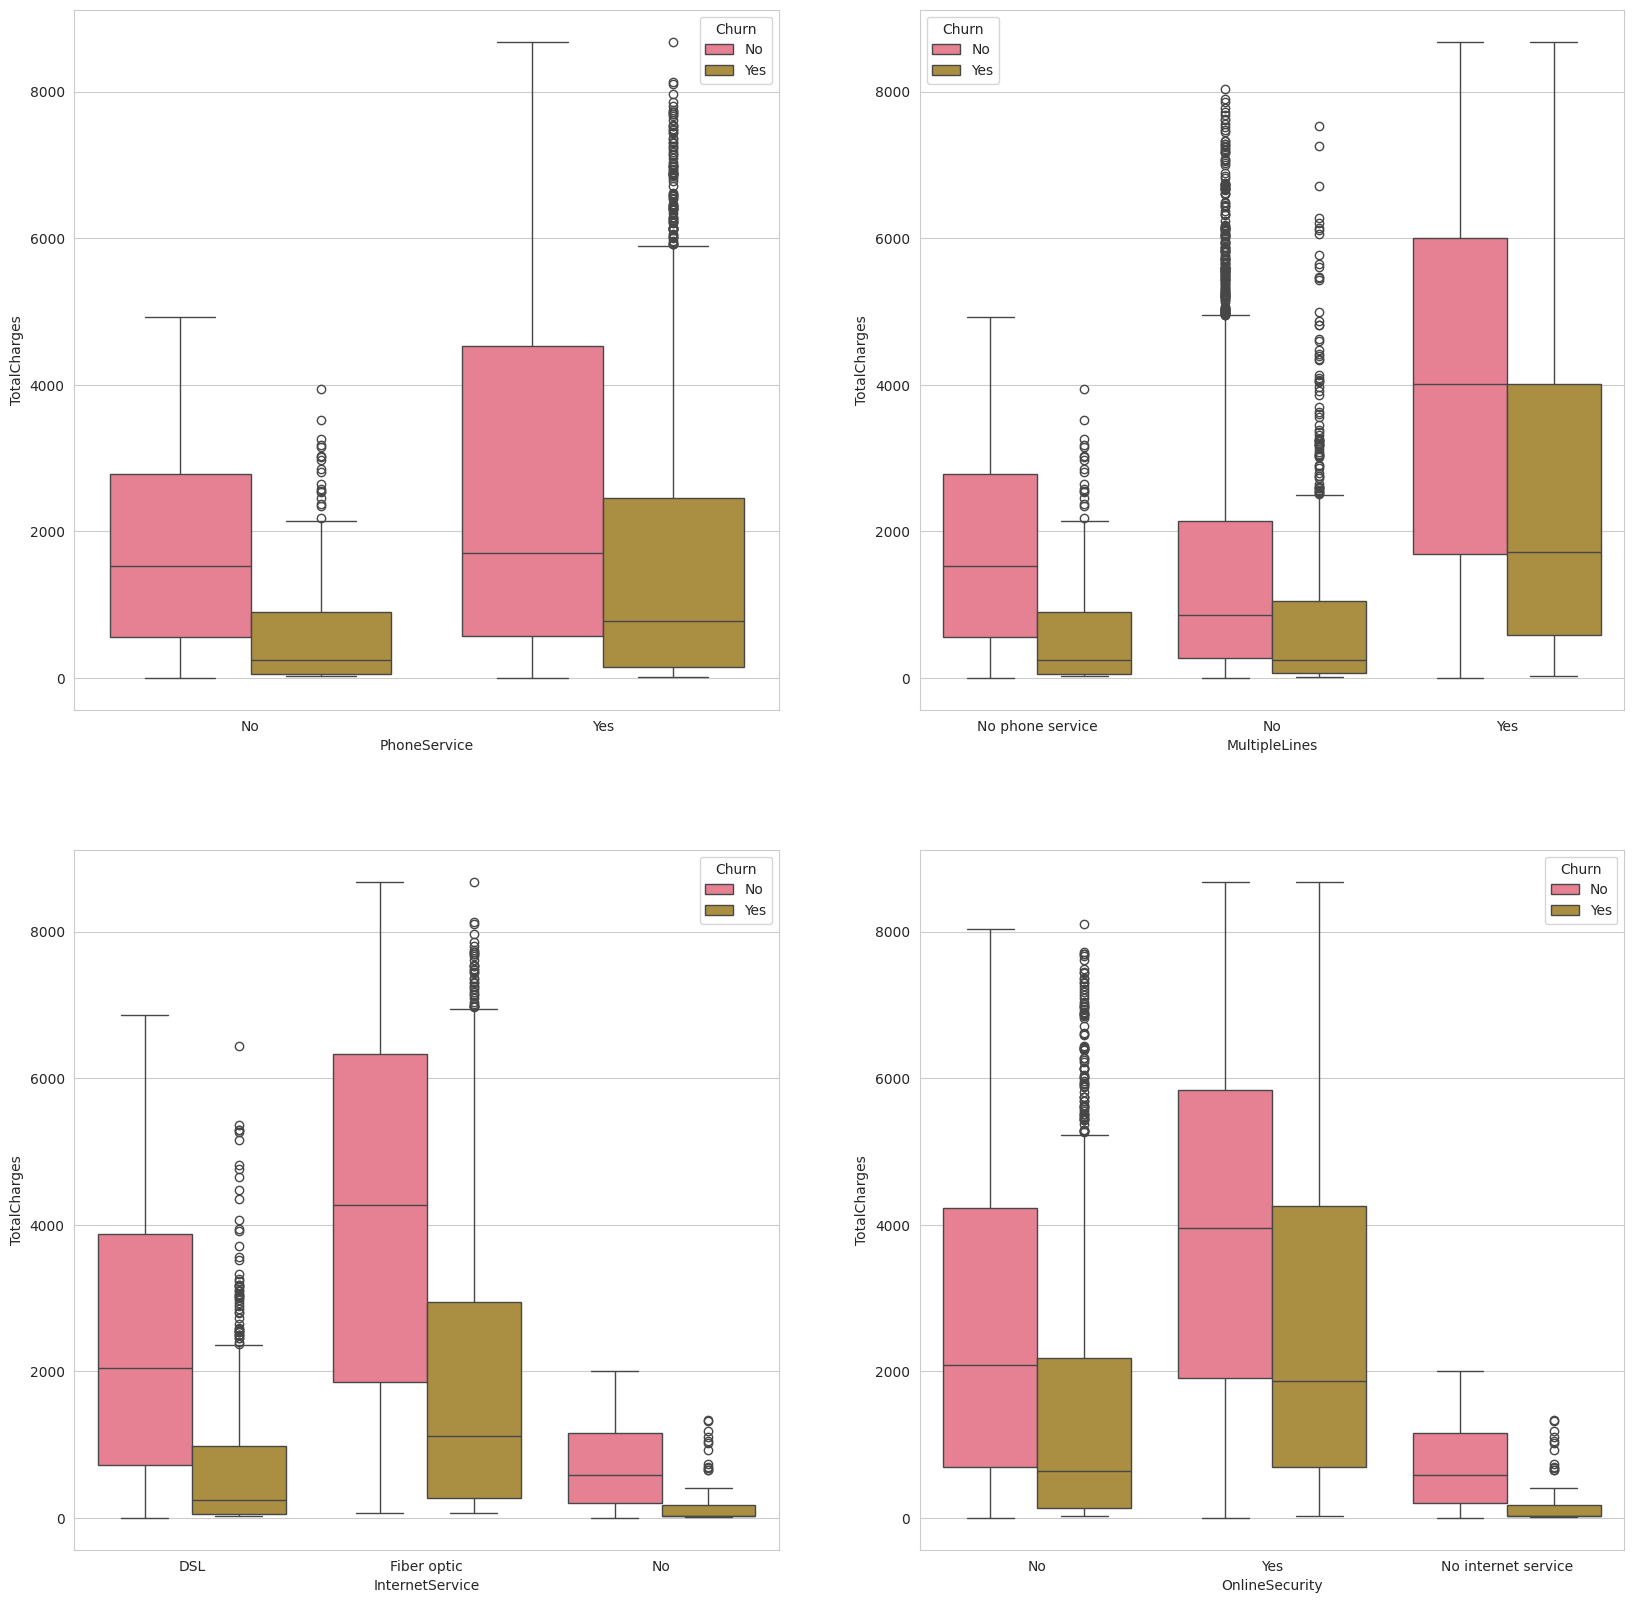

In [36]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x2 = ['PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x2[i] , y='TotalCharges', data =df, hue='Churn')

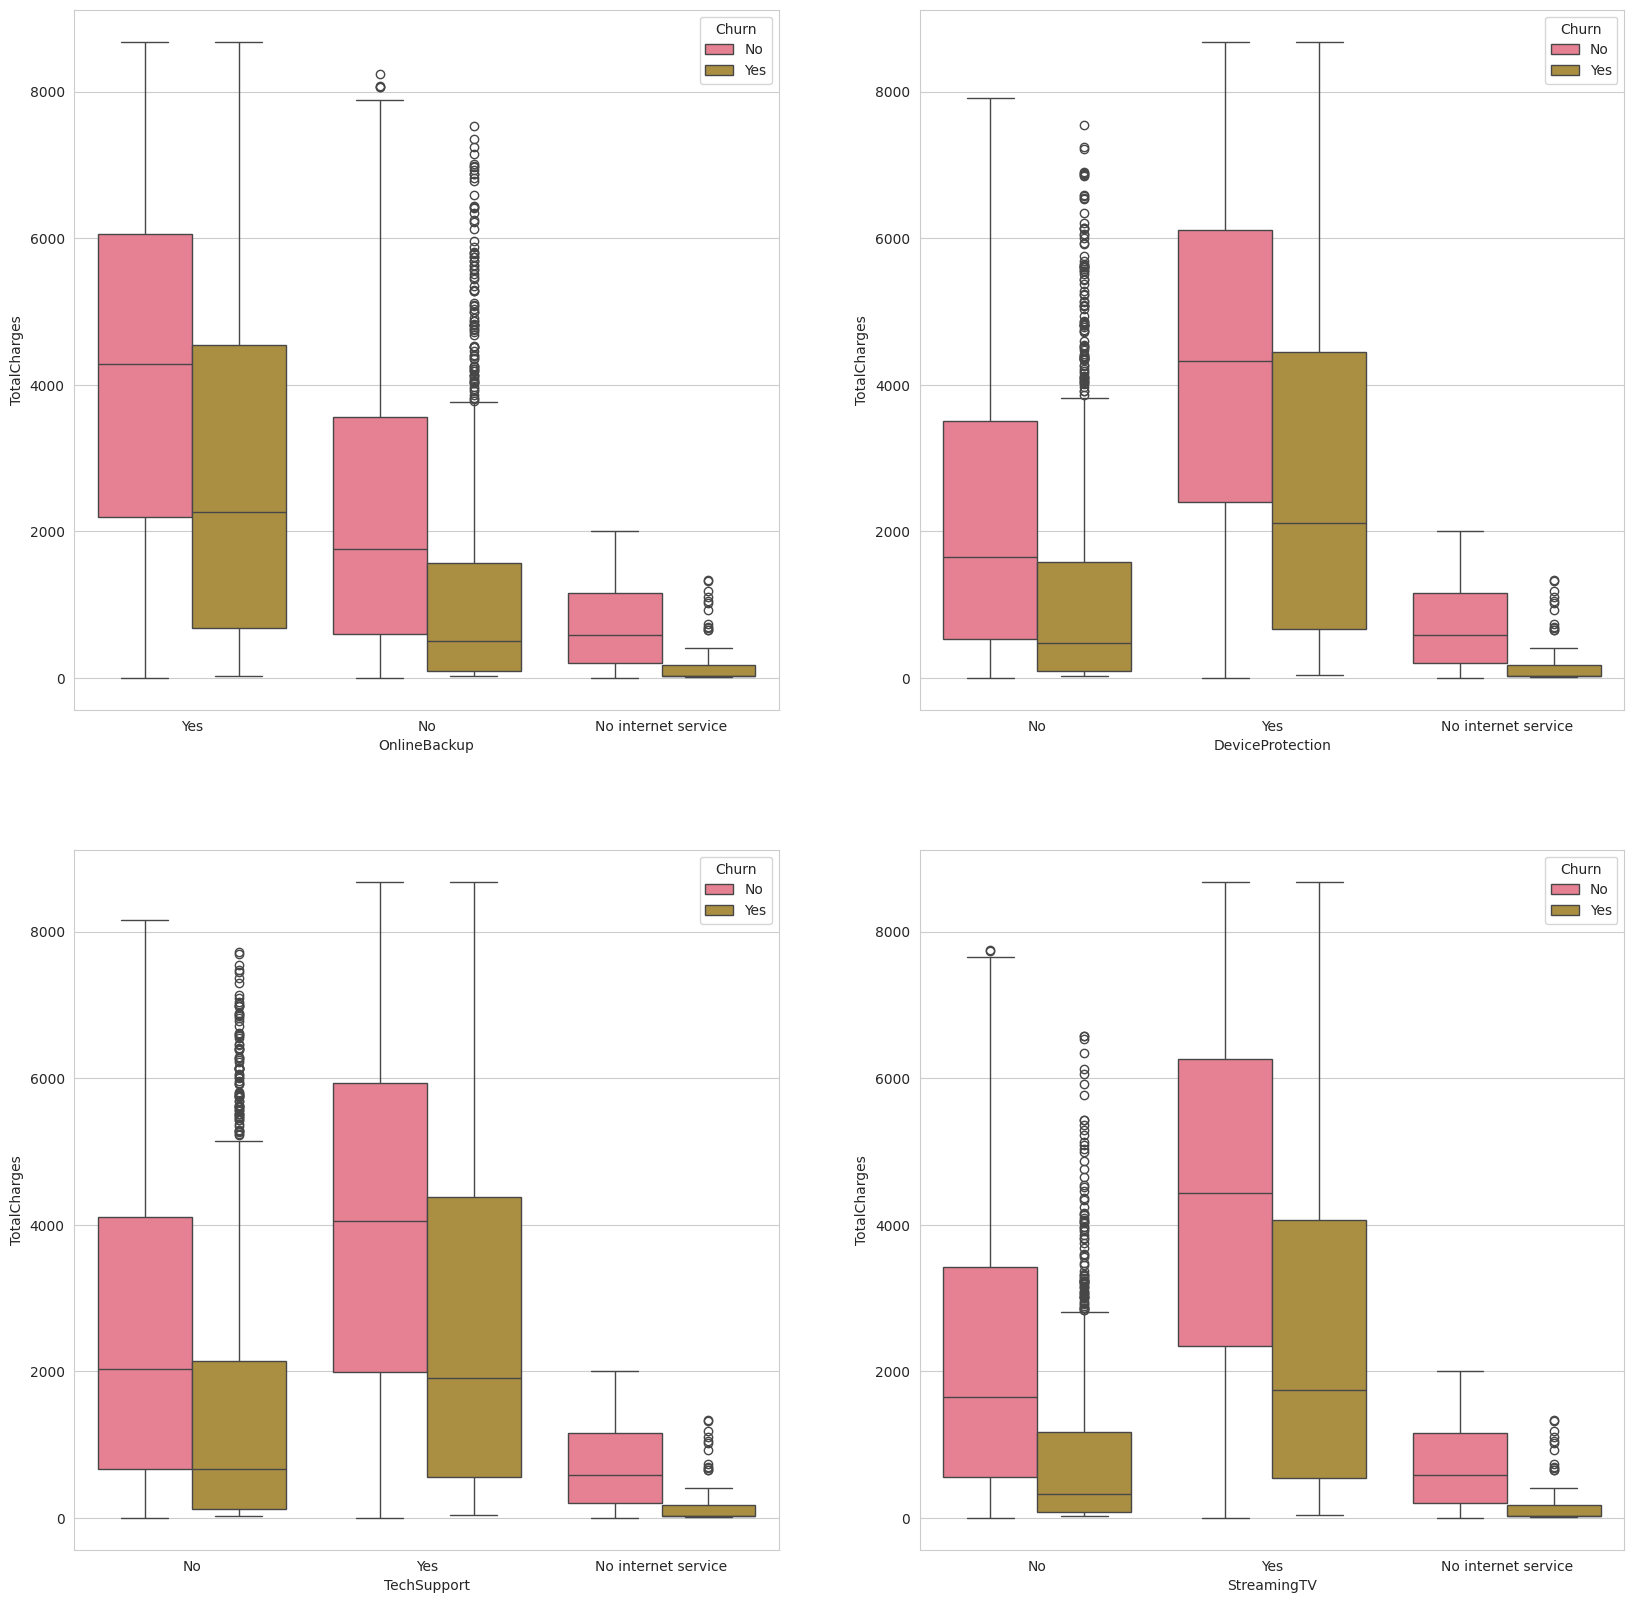

In [37]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x3 = ['OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x3[i] , y='TotalCharges', data =df, hue='Churn')

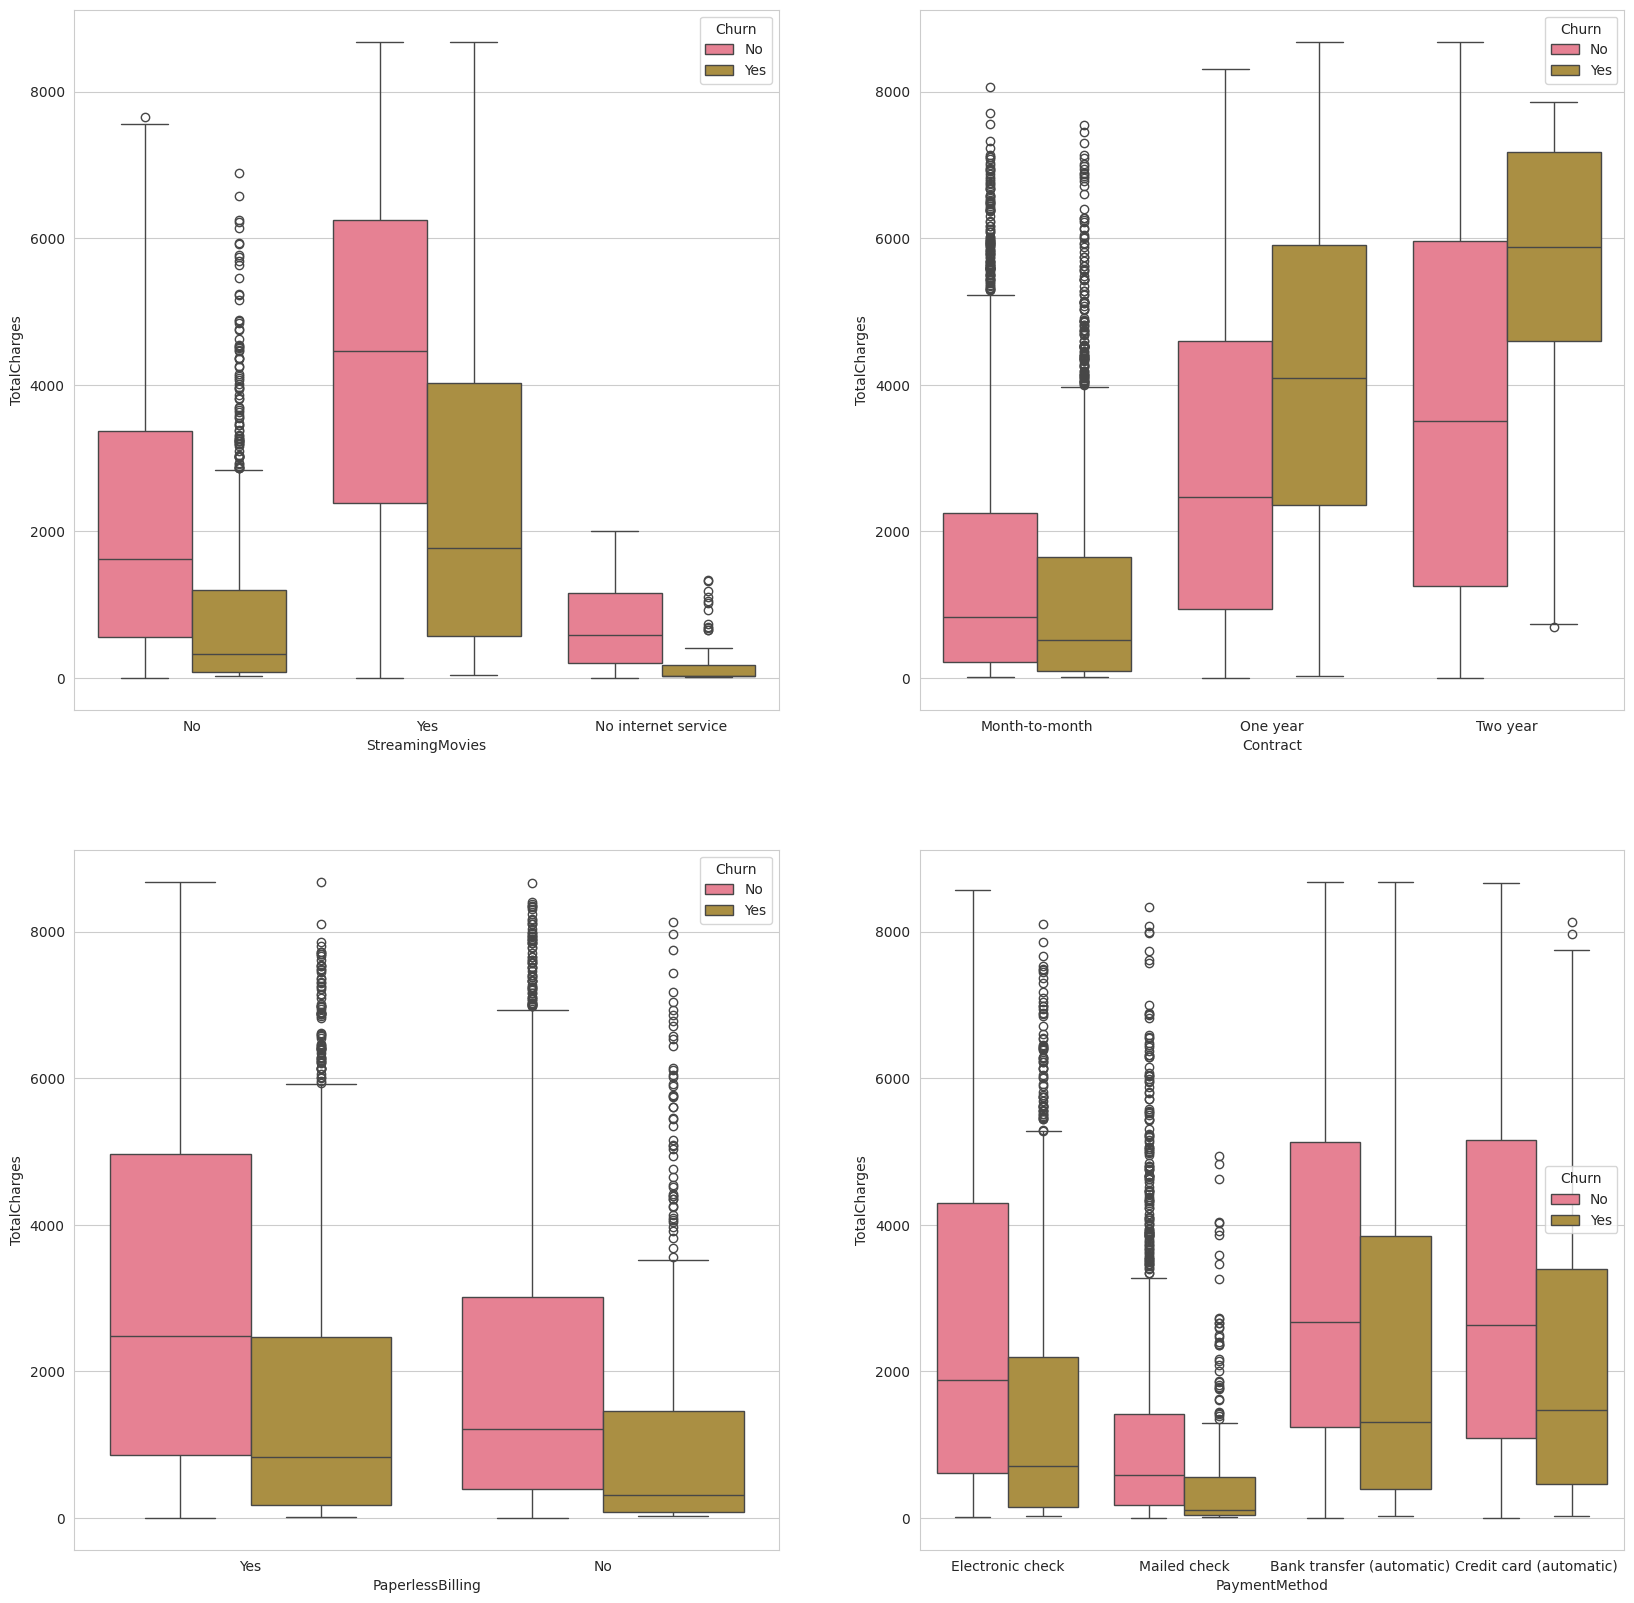

In [38]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x4 = ['StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x4[i] , y='TotalCharges', data =df, hue='Churn')

In [51]:
data = df.copy(deep=True)

In [52]:
bins = [0,6,12,18,24,36,48,60,72,1000]
bin_labels = ['0-6', '6-12', '12-18', '18-24', '24-36', '36-48', '48-60', '60-72', '72+']

data['tenure_group'] = pd.cut(data['tenure'], bins = bins, labels = bin_labels, right = False)

In [53]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,24-36
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,36-48
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6


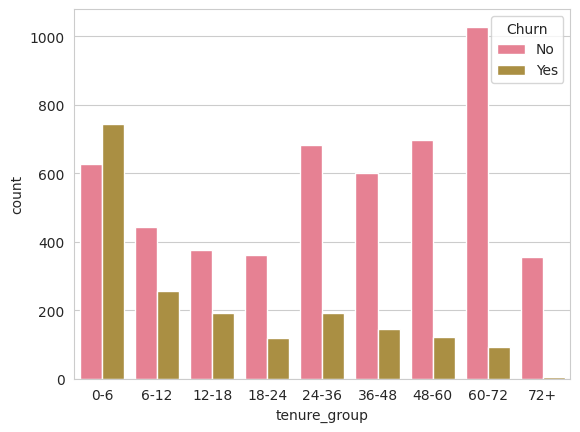

In [26]:
sns.countplot(x='tenure_group', data=data, hue='Churn')
plt.show()

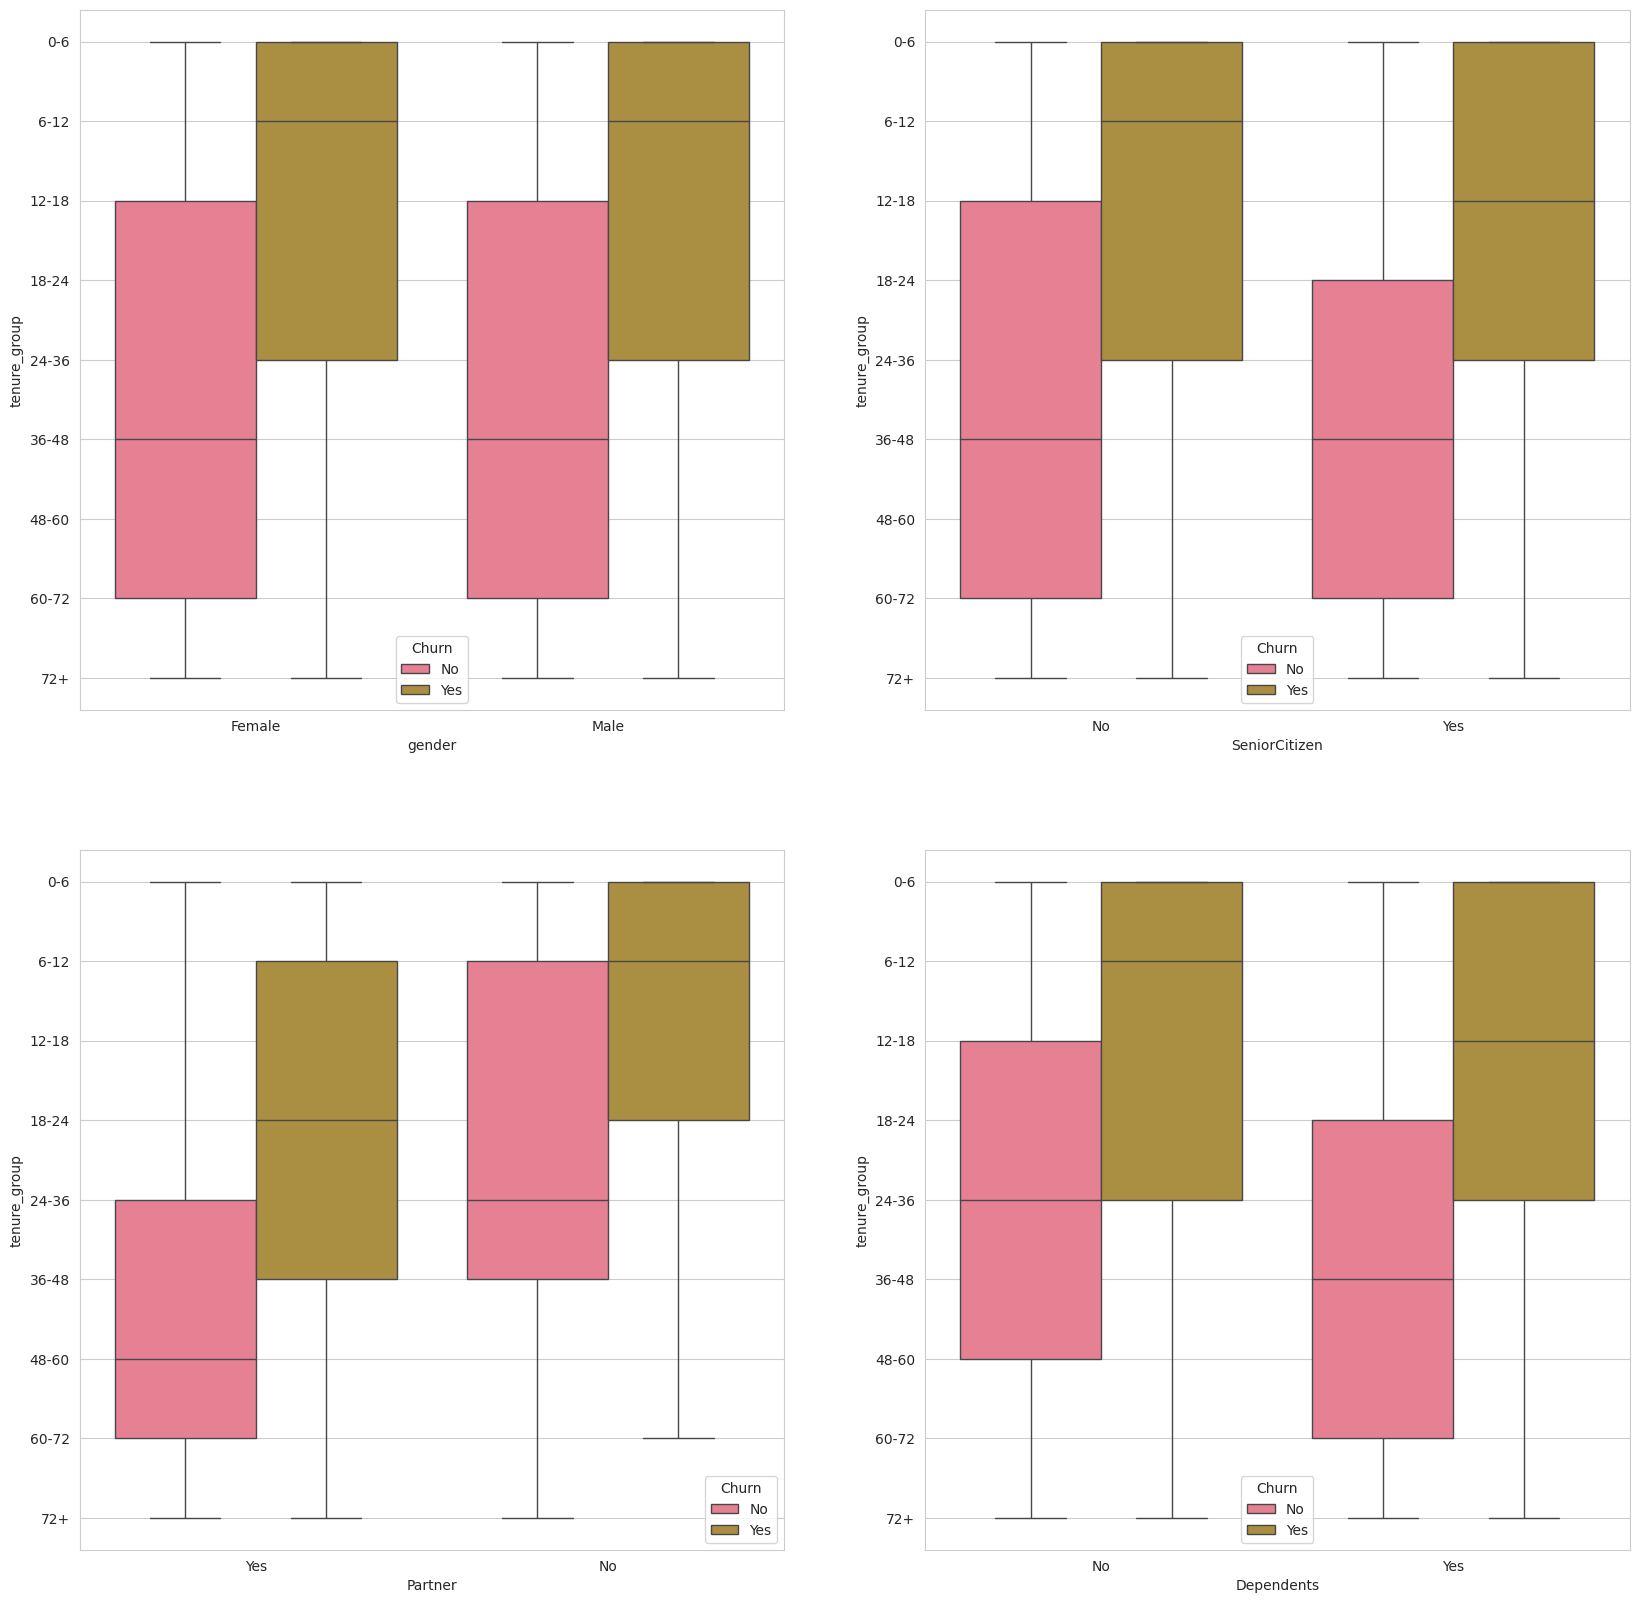

In [27]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x1 = ['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x1[i] , y='tenure_group', data =data, hue='Churn')

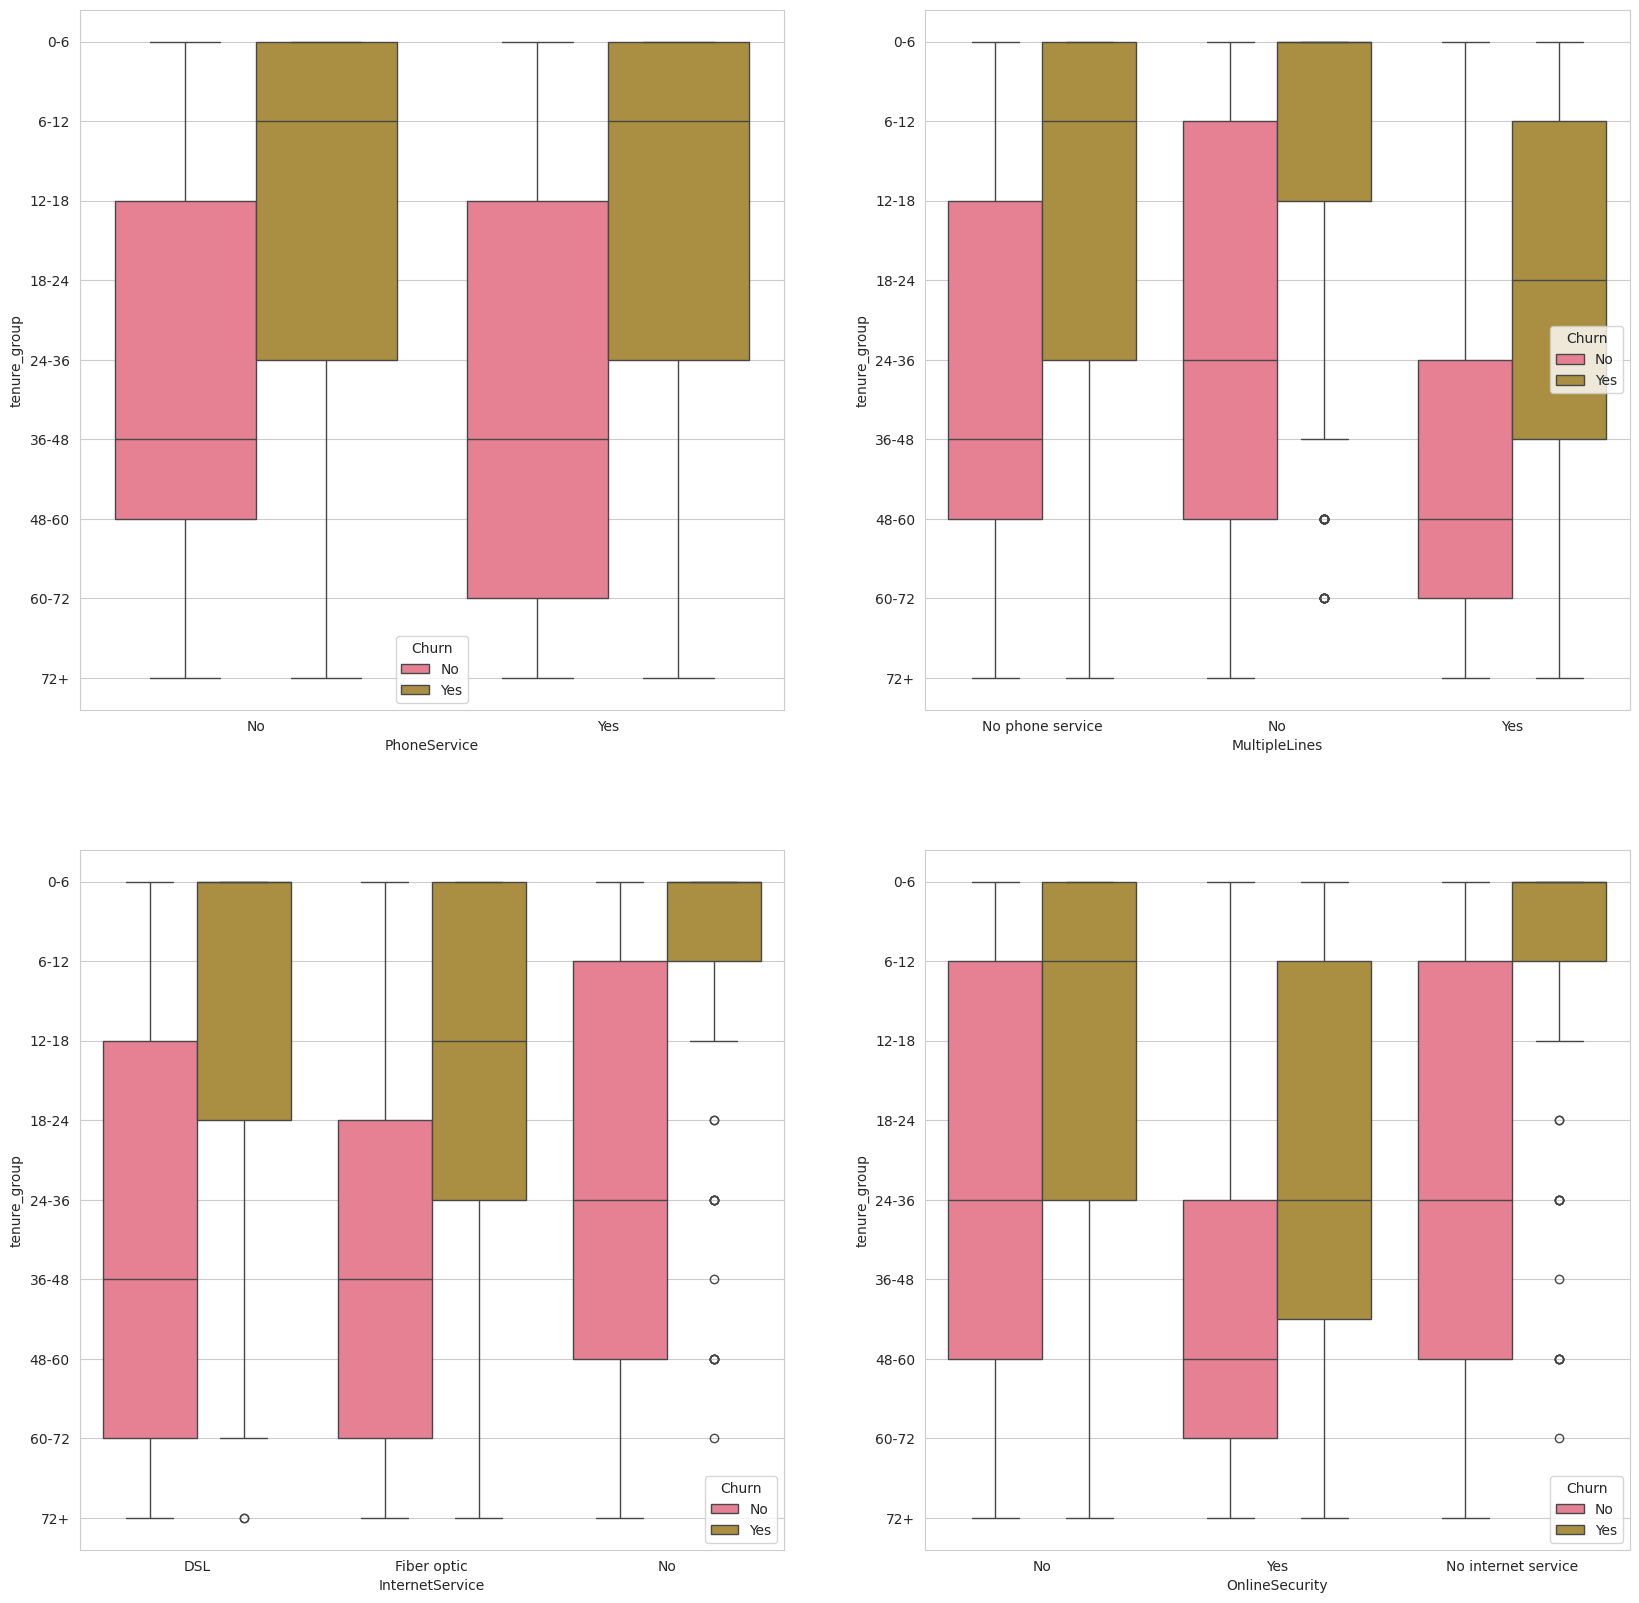

In [28]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x2 = ['PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x2[i] , y='tenure_group', data =data, hue='Churn')

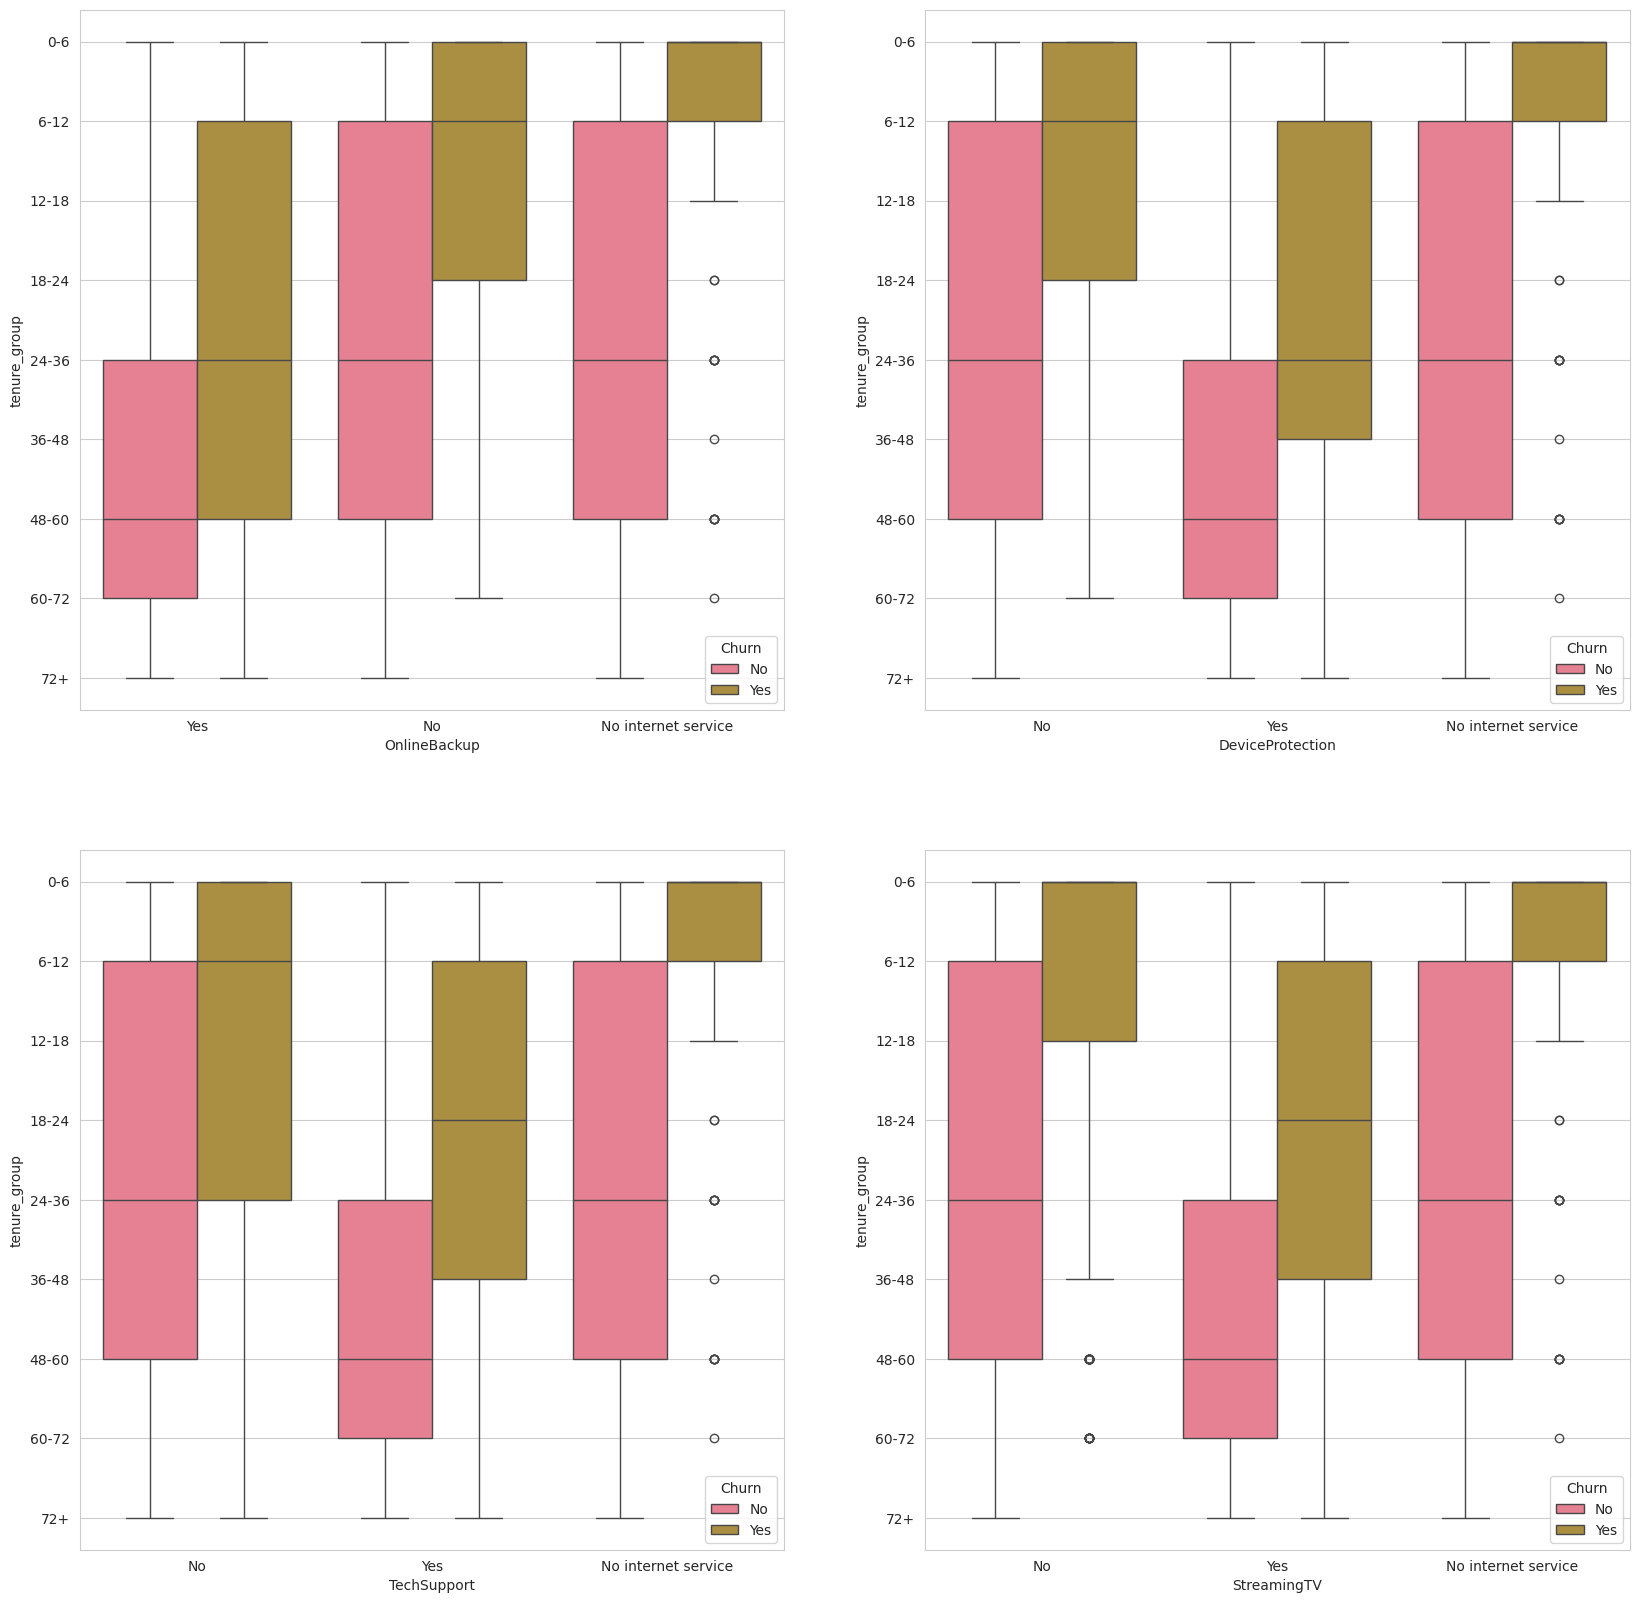

In [29]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x3 = ['OnlineBackup',
 'DeviceProtection', 
 'TechSupport',
 'StreamingTV']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x3[i] , y='tenure_group', data =data, hue='Churn')

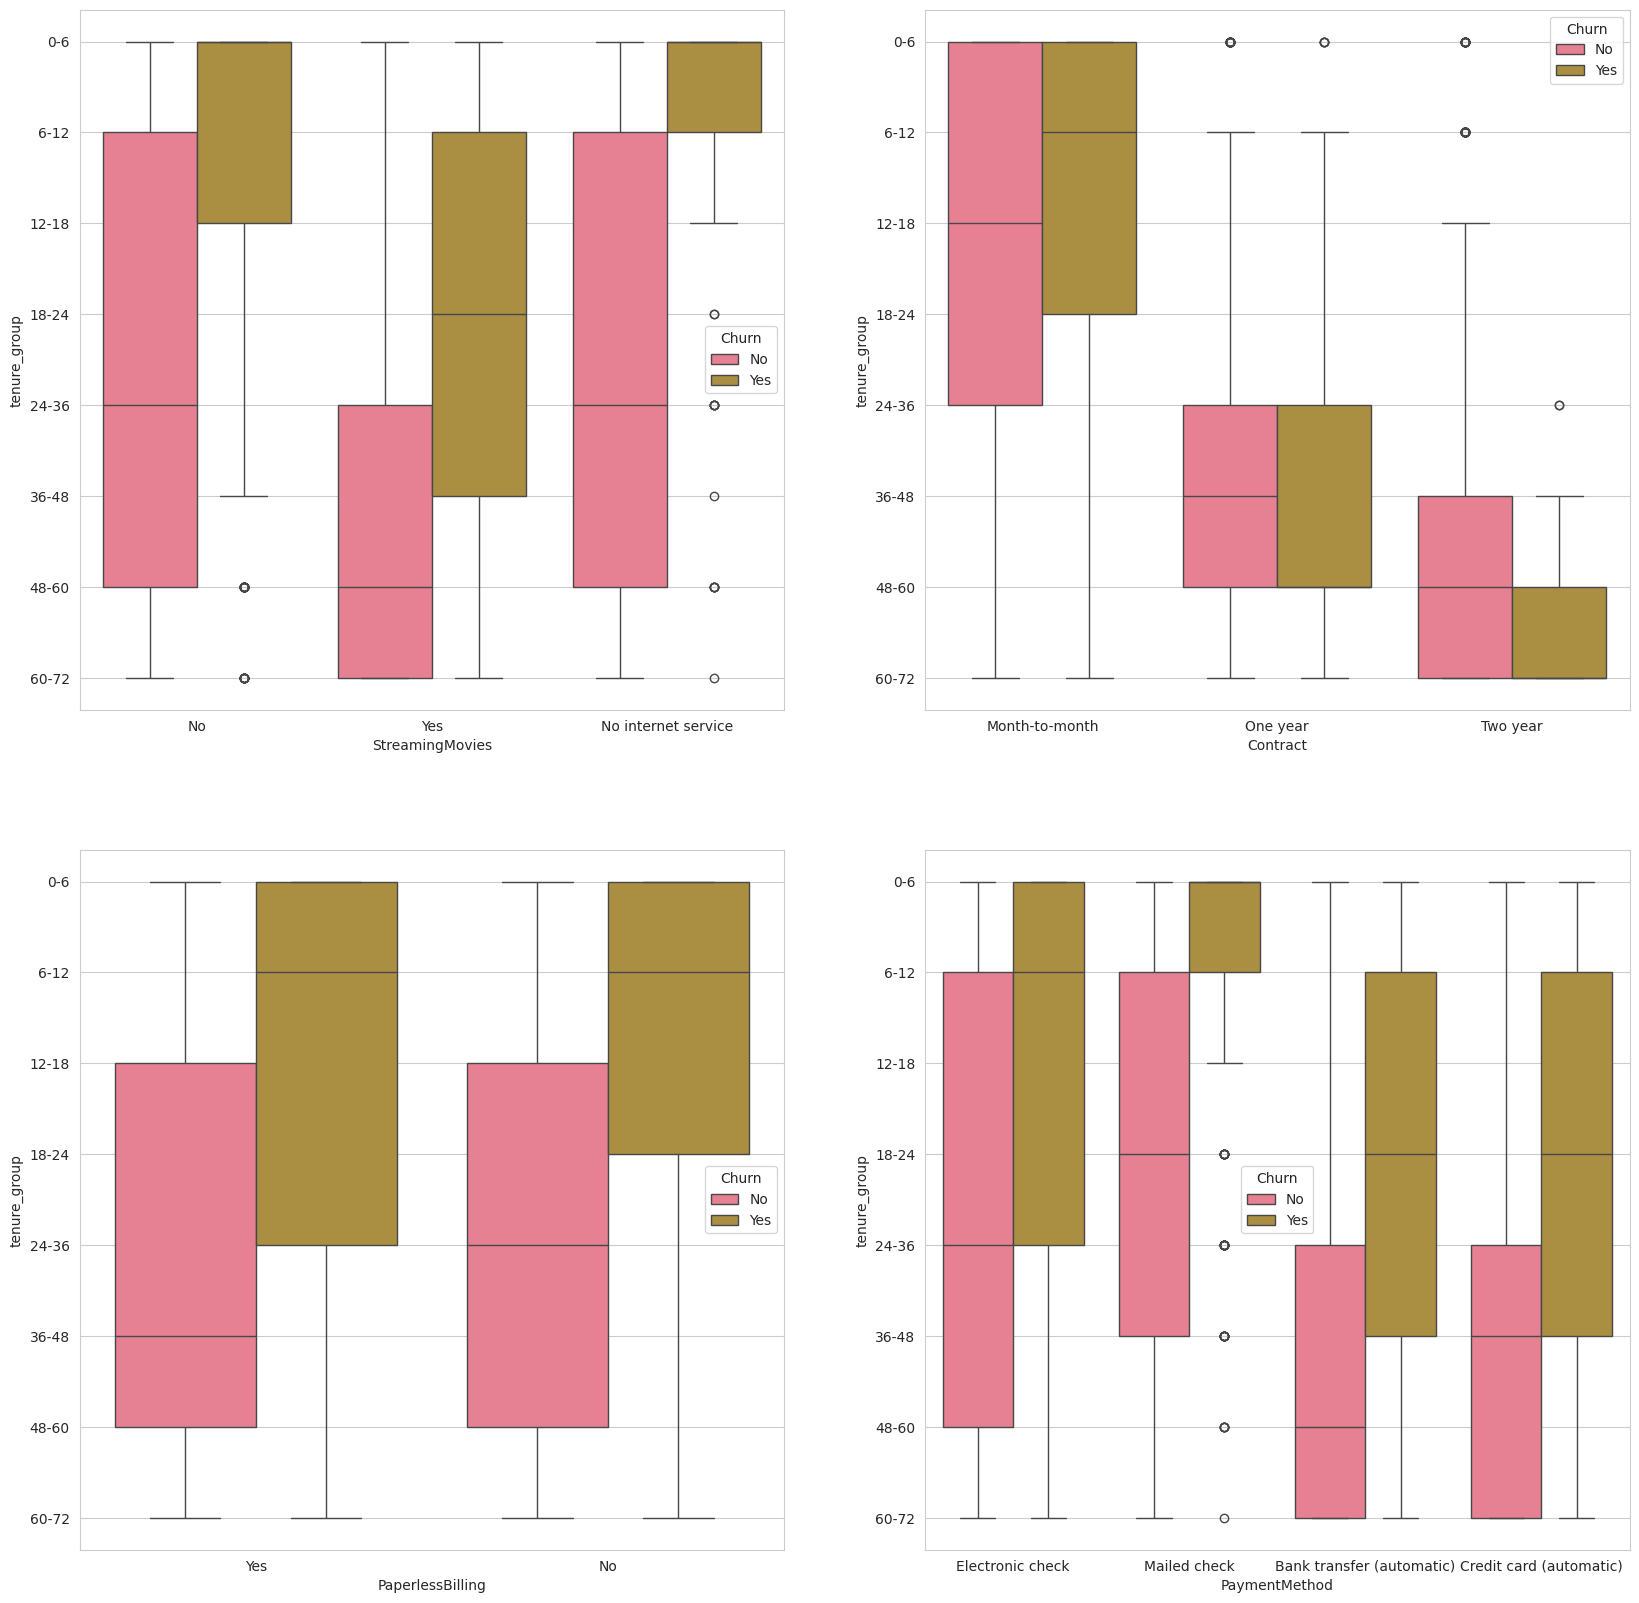

In [46]:
fig = plt.subplots(nrows =2, ncols =2, figsize=(20,20))
x4 = ['StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = x4[i] , y='tenure_group', data =data, hue='Churn')

In [54]:
data['Average_Monthly_Spend'] = np.where(
    data['tenure'] == 0,
    0,
    data['TotalCharges'] / data['tenure']
)

In [55]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,Average_Monthly_Spend
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6,29.850000
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,24-36,55.573529
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6,54.075000
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,36-48,40.905556
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6,75.825000


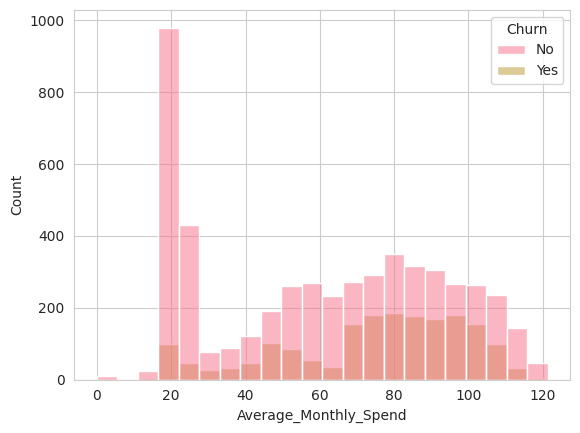

In [49]:
sns.histplot(x='Average_Monthly_Spend', data=data, hue='Churn')
plt.show()

In [56]:
services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in services:
    data[col] = data[col].replace({
        'Yes' : 1,
        'No' : 0,
        'No internet service' : 0
    })

data['HasInternet'] = (data['InternetService'] != 'No').astype(int)

In [57]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,Average_Monthly_Spend,HasInternet
0,Female,No,Yes,No,1,No,No phone service,DSL,0,1,...,0,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6,29.850000,1
1,Male,No,No,No,34,Yes,No,DSL,1,0,...,0,One year,No,Mailed check,56.95,1889.50,No,24-36,55.573529,1
2,Male,No,No,No,2,Yes,No,DSL,1,1,...,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6,54.075000,1
3,Male,No,No,No,45,No,No phone service,DSL,1,0,...,0,One year,No,Bank transfer (automatic),42.30,1840.75,No,36-48,40.905556,1
4,Female,No,No,No,2,Yes,No,Fiber optic,0,0,...,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6,75.825000,1


In [58]:
data['NumServices'] = data[services].sum(axis=1)

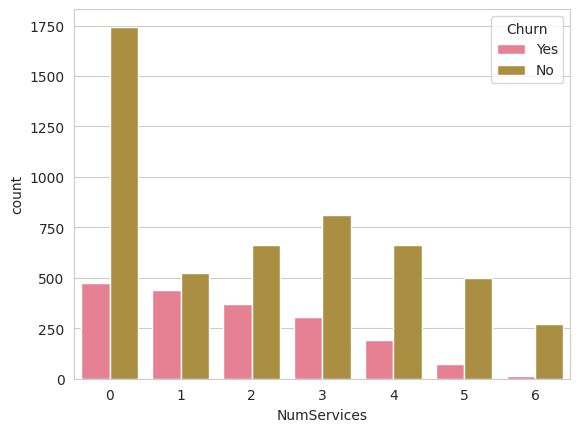

In [33]:
sns.countplot(x='NumServices', data=data, hue='Churn')
plt.show()

In [59]:
data['ContractMonths'] = data['Contract'].map({
    'Month-to-month': 1,
    'One year': 12,
    'Two year' : 24
    
})

In [60]:
# Indicator
data['IsMonthToMonth'] = (data['Contract'] == 'Month-to-month').astype(int)

# Progress only for long-term
data['ContractProgress'] = np.where(
    data['Contract'] != 'Month-to-month',
    (data['tenure'] / data['ContractMonths']).clip(upper=1),
    np.nan
)

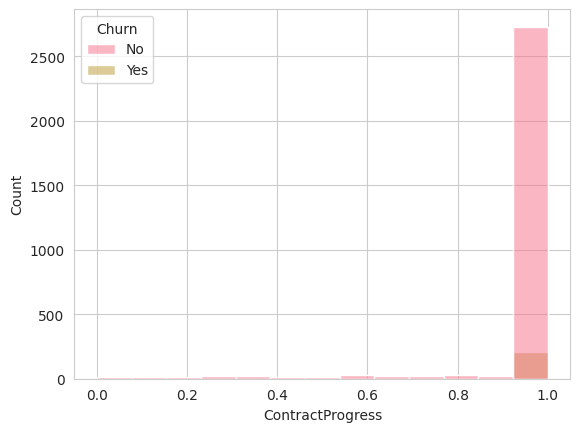

In [36]:
sns.histplot(x='ContractProgress', data=data, hue='Churn')
plt.show()

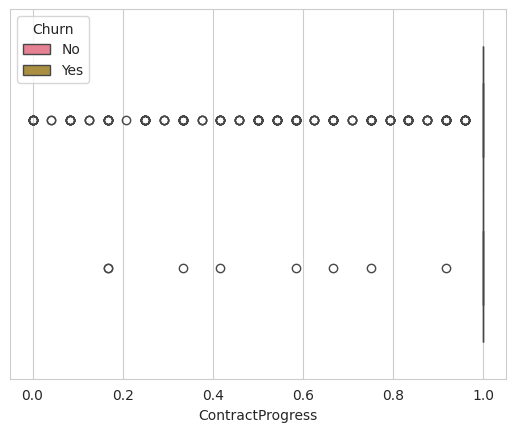

In [37]:
sns.boxplot(x='ContractProgress', data=data, hue='Churn')
plt.show()

In [61]:
data['Churn'] = data['Churn'].map({
    'Yes':1,
    'No':0})

In [62]:
data.groupby(pd.cut(data['ContractProgress'], bins=5))['Churn'].mean()

ContractProgress
(-0.001, 0.2]    0.057143
(0.2, 0.4]       0.023810
(0.4, 0.6]       0.032258
(0.6, 0.8]       0.040000
(0.8, 1.0]       0.069486
Name: Churn, dtype: float64

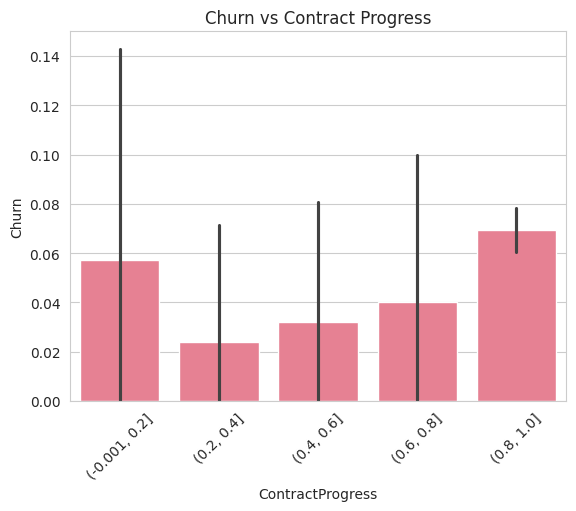

In [105]:
sns.barplot(
    x=pd.cut(data['ContractProgress'], bins=5),
    y=data['Churn']
)
plt.xticks(rotation=45)
plt.title("Churn vs Contract Progress")
plt.show()

In [63]:
profile = data[data['Churn'] == 0].describe().T

In [64]:
profile

,count,mean,std,min,25%,50%,75%,max
tenure,5174.0,37.569965,24.113777,0.00,15.000000,38.000000,61.000000,72.00000
OnlineSecurity,5174.0,0.333204,0.471405,0.00,0.000000,0.000000,1.000000,1.00000
OnlineBackup,5174.0,0.368380,0.482412,0.00,0.000000,0.000000,1.000000,1.00000
DeviceProtection,5174.0,0.362775,0.480847,0.00,0.000000,0.000000,1.000000,1.00000
TechSupport,5174.0,0.335137,0.472084,0.00,0.000000,0.000000,1.000000,1.00000
StreamingTV,5174.0,0.365868,0.481719,0.00,0.000000,0.000000,1.000000,1.00000
StreamingMovies,5174.0,0.369927,0.482831,0.00,0.000000,0.000000,1.000000,1.00000
MonthlyCharges,5174.0,61.265124,31.092648,18.25,25.100000,64.425000,88.400000,118.75000
TotalCharges,5174.0,2549.911442,2329.954215,0.00,572.900000,1679.525000,4262.850000,8672.45000
Churn,5174.0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.00000


In [65]:
data.groupby('IsMonthToMonth')['Churn'].mean()

IsMonthToMonth
0    0.067551
1    0.427097
Name: Churn, dtype: float64

In [66]:

data.drop(columns=['Average_Monthly_Spend'], inplace=True)

data['gender'] = data['gender'].map({'Male': 0, 'Female': 1})
data['SeniorCitizen'] = data['SeniorCitizen'].map({'No': 0, 'Yes': 1})

for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    data[col] = data[col].map({'No': 0, 'Yes': 1})


data['MultipleLines'] = data['MultipleLines'].map({
    'No': 0,
    'Yes': 1,
    'No phone service': 0
})
data['HasPhoneService'] = (data['PhoneService'] == 'Yes').astype(int)

data = pd.get_dummies(data, columns=['InternetService', 'PaymentMethod'], drop_first=True)

bin_labels = ['0-6', '6-12', '12-18', '18-24', '24-36', '36-48', '48-60', '60-72', '72+']

data['tenure_group'] = data['tenure_group'].map({
    '0-6': 0,
    '6-12': 1,
    '12-18': 2,
    '18-24': 3,
    '24-36': 4,
    '36-48' : 5,
    '48-60':6,
    '60-72':7,
    '72+':8
})


In [67]:
data = pd.get_dummies(data, columns=['Contract'], drop_first=True)

In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   gender                                 7043 non-null   int64   
 1   SeniorCitizen                          7043 non-null   int64   
 2   Partner                                7043 non-null   int64   
 3   Dependents                             7043 non-null   int64   
 4   tenure                                 7043 non-null   int64   
 5   PhoneService                           7043 non-null   int64   
 6   MultipleLines                          7043 non-null   int64   
 7   OnlineSecurity                         7043 non-null   int64   
 8   OnlineBackup                           7043 non-null   int64   
 9   DeviceProtection                       7043 non-null   int64   
 10  TechSupport                            7043 non-null   int64

In [69]:
bool_cols = data.select_dtypes(include = 'bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   gender                                 7043 non-null   int64   
 1   SeniorCitizen                          7043 non-null   int64   
 2   Partner                                7043 non-null   int64   
 3   Dependents                             7043 non-null   int64   
 4   tenure                                 7043 non-null   int64   
 5   PhoneService                           7043 non-null   int64   
 6   MultipleLines                          7043 non-null   int64   
 7   OnlineSecurity                         7043 non-null   int64   
 8   OnlineBackup                           7043 non-null   int64   
 9   DeviceProtection                       7043 non-null   int64   
 10  TechSupport                            7043 non-null   int64

In [74]:
data['tenure_group'] = data['tenure_group'].cat.as_ordered()

In [75]:
data['tenure_group'] = data['tenure_group'].cat.codes

In [85]:
from sklearn.model_selection import train_test_split

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42, stratify=y)

In [86]:
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (5282, 30)
y_train (5282,)
X_test (1761, 30)
y_test (1761,)


In [87]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [83]:
data['ContractProgress'] = data['ContractProgress'].fillna(0)

In [88]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train) 

In [90]:
print("X_train", X_train_resampled.shape)
print("y_train", y_train_resampled.shape)

X_train (7760, 30)
y_train (7760,)


In [91]:
print("X_test", X_test_scaled.shape)

X_test (1761, 30)


In [93]:
y_train_resampled.value_counts()

Churn
0    3880
1    3880
Name: count, dtype: int64

In [94]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000)

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [105]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [97]:
from sklearn.metrics import classification_report, roc_auc_score
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1294
           1       0.52      0.81      0.63       467

    accuracy                           0.75      1761
   macro avg       0.72      0.77      0.72      1761
weighted avg       0.81      0.75      0.76      1761

ROC-AUC: 0.8463754637612568


In [106]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1294
           1       0.63      0.48      0.54       467

    accuracy                           0.79      1761
   macro avg       0.73      0.69      0.70      1761
weighted avg       0.77      0.79      0.78      1761

ROC-AUC: 0.8299282804179394


In [107]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1294
           1       0.61      0.51      0.56       467

    accuracy                           0.78      1761
   macro avg       0.72      0.70      0.71      1761
weighted avg       0.77      0.78      0.78      1761

ROC-AUC: 0.8201276522510418


In [114]:
import matplotlib.pyplot as plt
import pandas as pd

feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(15)

TotalCharges                      0.012764
DeviceProtection                  0.012792
NumServices                       0.013333
TechSupport                       0.014138
PaperlessBilling                  0.014775
OnlineBackup                      0.015023
OnlineSecurity                    0.015796
MultipleLines                     0.016183
PaymentMethod_Electronic check    0.016497
PhoneService                      0.018143
StreamingMovies                   0.018265
tenure                            0.019873
HasInternet                       0.075354
ContractMonths                    0.264026
InternetService_Fiber optic       0.368528
dtype: float32

In [113]:
import matplotlib.pyplot as plt
import pandas as pd

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(15)


MultipleLines                     0.019351
SeniorCitizen                     0.019618
Partner                           0.022287
PaperlessBilling                  0.025647
gender                            0.028090
PaymentMethod_Electronic check    0.029384
ContractProgress                  0.032294
IsMonthToMonth                    0.036633
InternetService_Fiber optic       0.037655
NumServices                       0.038147
ContractMonths                    0.043037
tenure_group                      0.058960
tenure                            0.119195
MonthlyCharges                    0.153638
TotalCharges                      0.153928
dtype: float64

In [117]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(random_state=42)
DT.fit(X_train, y_train)
y_pred_dt = DT.predict(X_test)
y_prob_dt = DT.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1294
           1       0.50      0.49      0.50       467

    accuracy                           0.73      1761
   macro avg       0.66      0.66      0.66      1761
weighted avg       0.73      0.73      0.73      1761

ROC-AUC: 0.6562159729140258


In [161]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]
y_pred_gb = (y_prob_gb > 0.28).astype(int)
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1294
           1       0.53      0.77      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.76      0.73      1761
weighted avg       0.80      0.76      0.77      1761

ROC-AUC: 0.8470944798758229


In [123]:
from sklearn.svm import SVC
svc = SVC(probability=True)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)
y_prob_svc = svc.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_svc))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svc))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1294
           1       0.65      0.51      0.57       467

    accuracy                           0.80      1761
   macro avg       0.74      0.71      0.72      1761
weighted avg       0.79      0.80      0.79      1761

ROC-AUC: 0.8003766353686426


In [127]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1294
           1       0.56      0.54      0.55       467

    accuracy                           0.76      1761
   macro avg       0.70      0.69      0.69      1761
weighted avg       0.76      0.76      0.76      1761

ROC-AUC: 0.7820528944328791


In [125]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1294
           1       0.48      0.82      0.60       467

    accuracy                           0.71      1761
   macro avg       0.70      0.75      0.69      1761
weighted avg       0.80      0.71      0.73      1761

ROC-AUC: 0.8323194847575202


In [130]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
y_prob_lda = lda.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lda))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lda))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1294
           1       0.64      0.53      0.58       467

    accuracy                           0.80      1761
   macro avg       0.74      0.71      0.72      1761
weighted avg       0.79      0.80      0.79      1761

ROC-AUC: 0.8426438611413574


In [151]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

gb = GradientBoostingClassifier(random_state=42)
lda = LinearDiscriminantAnalysis()

In [152]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('gb', gb),
        ('lda', lda)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('model',
                                               LogisticRegression(max_iter=1000))])),
                             ('gb',
                              GradientBoostingClassifier(random_state=42)),
                             ('lda', LinearDiscriminantAnalysis())],
                 voting='soft')

In [154]:
y_pred_voting = ensemble.predict(X_test)
y_prob_voting = ensemble.predict_proba(X_test)[:, 1]
y_pred_voting = (y_prob > 0.28).astype(int)
print(classification_report(y_test, y_pred_voting))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_voting))

              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1294
           1       0.54      0.77      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.76      0.78      1761

ROC-AUC: 0.8489139464304035


In [147]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_voting)

In [148]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

In [149]:
best_threshold

np.float64(0.2783751147172113)

In [135]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_voting))

[[1170  124]
 [ 225  242]]


In [139]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('gb', gb),
        ('lda', lda)
    ],
    final_estimator=LogisticRegression()
)
stack.fit(X_train, y_train)

StackingClassifier(estimators=[('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 LogisticRegression(max_iter=1000))])),
                               ('gb',
                                GradientBoostingClassifier(random_state=42)),
                               ('lda', LinearDiscriminantAnalysis())],
                   final_estimator=LogisticRegression())

In [140]:
y_pred_stacking = ensemble.predict(X_test)
y_prob_stacking = ensemble.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_stacking))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_stacking))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1294
           1       0.66      0.52      0.58       467

    accuracy                           0.80      1761
   macro avg       0.75      0.71      0.73      1761
weighted avg       0.79      0.80      0.79      1761

ROC-AUC: 0.8489139464304035


In [141]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [142]:
cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)
lgb = LGBMClassifier(random_state=42)

lgb.fit(X_train, y_train)
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001839 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265430 -> initscore=-1.017935
[LightGBM] [Info] Start training from score -1.017935


GradientBoostingClassifier(random_state=42)

In [143]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('cat', cat),
        ('lgb', lgb),
        ('gb', gb)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265430 -> initscore=-1.017935
[LightGBM] [Info] Start training from score -1.017935


VotingClassifier(estimators=[('cat',
                              CatBoostClassifier(random_state=42, verbose=0)),
                             ('lgb', LGBMClassifier(random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42))],
                 voting='soft')

In [144]:
y_pred = ensemble.predict(X_test)
y_prob = ensemble.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1294
           1       0.65      0.50      0.57       467

    accuracy                           0.80      1761
   macro avg       0.74      0.70      0.72      1761
weighted avg       0.79      0.80      0.79      1761

ROC-AUC: 0.8437939559621246


In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
gb = GradientBoostingClassifier(random_state=42)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [156]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('gb', gb),
        ('rf', rf)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('model',
                                               LogisticRegression(max_iter=1000))])),
                             ('gb',
                              GradientBoostingClassifier(random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_estimators=200,
                                                     random_state=42))],
                 voting='soft')

In [158]:
from sklearn.metrics import classification_report, roc_auc_score

y_prob = ensemble.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.28).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1294
           1       0.54      0.80      0.64       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.76      0.78      1761

ROC-AUC: 0.8478846529361341


In [166]:
import shap

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test, check_additivity=False)
shap_values = explainer(X_test)


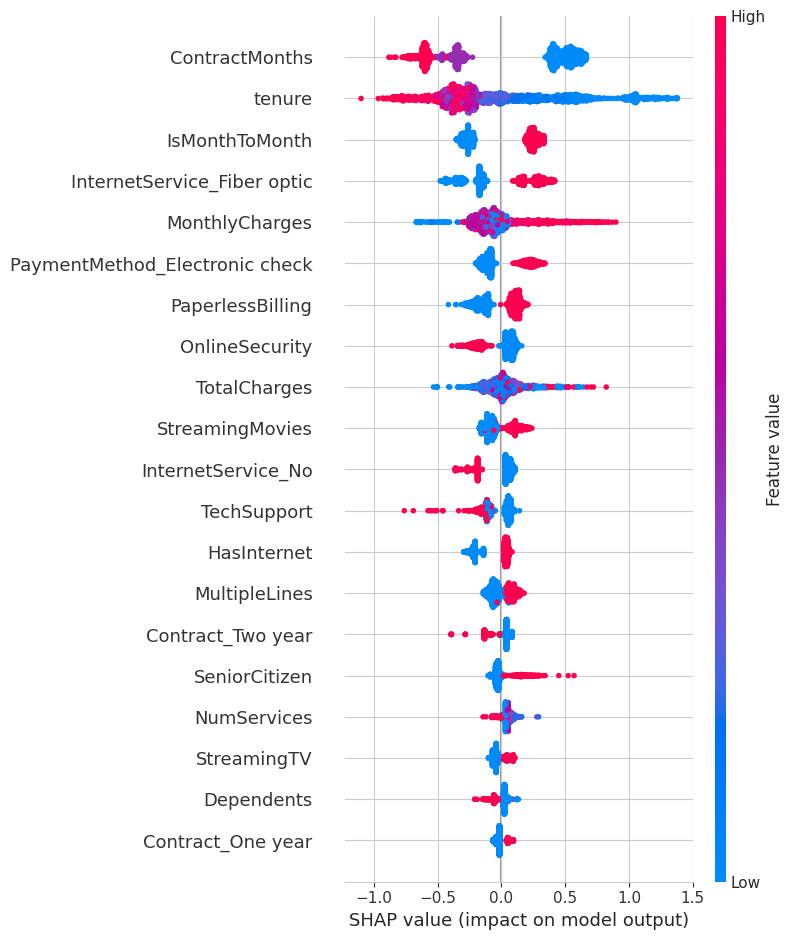

In [167]:
shap.summary_plot(shap_values, X_test)

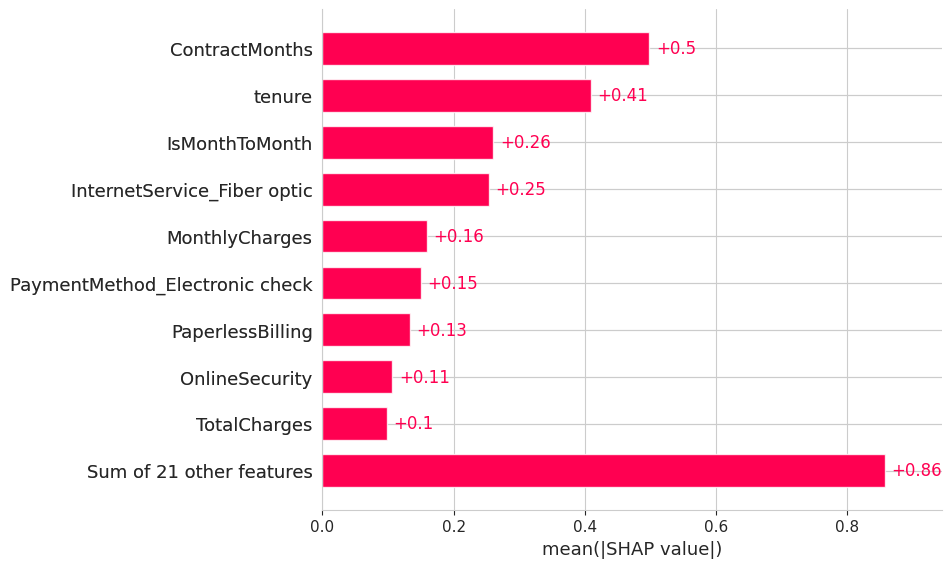

In [169]:
shap.plots.bar(shap_values)

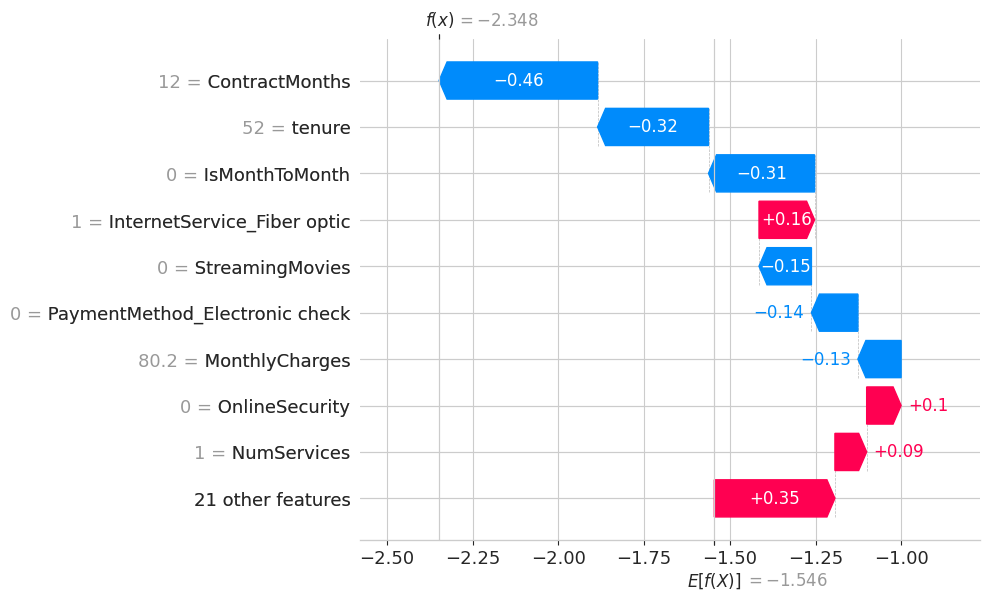

In [173]:
shap.plots.waterfall(shap_values[0])